# COMP 333 - Final Project

# Montreal Bixi Mobility & Climate Analysis (2025)

## Project Overview

This project synthesizes over 2 GB of raw Bixi Trip History with hourly meteorological data from Environment Canada to investigate how Montreal's climate influences urban cycling behaviour. The pipeline transitions from raw, high-volume data to a suite of supervised and unsupervised machine learning models, culminating in a fully interpreted classification system.

**Primary Objective:**

To determine whether environmental and temporal features can reliably classify Bixi trips as Short, Medium, or Long - and to identify which factors are the strongest predictors of trip-duration category in Montreal's bike-share network.

---

## Data Sources

**Main Dataset:**
- Bixi 2025 Trip History: 11.5 M trip records reflecting the most recent densified network. Source: https://bixi.com/en/open-data/

**Supporting Dataset:**
- Environment Canada Hourly Climate Data: Provides hourly temperature, precipitation, and windchill readings. Source: https://climate-change.canada.ca/climate-data/#/hourly-climate-data

### Why This Dataset?

**Scale:** The 2025 Bixi dataset exceeds 2 GB and 11 million rows, providing a genuine big-data challenge for pipeline design.

**Complexity:** Raw data requires significant programmatic handling - 13-digit Unix millisecond timestamps, coordinate gaps, ghost trips, and cross-file weather joins.

**Urban Context:** Montreal's extreme climate (−35°C winters, 35°C summers, heavy precipitation) provides a natural laboratory for testing how environmental shocks influence rider behaviour.

---

## Project Roadmap

### Phase 1: Foundation & Baseline

- **Data Retrieval & Integration:** Programmatic retrieval and synchronisation of Bixi trip records and Environment Canada hourly climate data.
- **Audit & Wrangling:** Pre- and post-cleaning quantitative and visual audits using `quantDDA()` and `vizDDA()`. Temporal alignment via Unix-millisecond conversion and weather join on rounded hour.
- **Regression Baseline:** Linear Regression and Decision Tree Regressor on weather features only, establishing a performance floor (R² ≈ 0.005) that motivates the Phase 2 classification reframing.

### Phase 2: Advanced Modeling & Feature Engineering

- **Problem Reframing:** Target converted to a 3-class variable (`duration_cat`) using data-driven tertile boundaries, ensuring balanced classes (~33% each).
- **Advanced Supervised Learning:** Three classifiers - Random Forest, LightGBM, and Linear SVC - evaluated first on baseline features, then on the full engineered feature set with systematic hyperparameter tuning. Evaluated by Accuracy, Macro F1, and ROC-AUC (OVR).
- **Feature Engineering & Selection:** 15 temporal, cyclical, interaction, and weather features engineered; ranked by mutual information (filter), RFE with LinearSVC (wrapper), and Random Forest impurity (embedded).
- **Unsupervised Learning:** PCA for dimensionality reduction and K-Means clustering to discover behavioural trip personas without using the class label.
- **Interpretation:** Feature importance (Random Forest and LightGBM) and Partial Dependence Plots to explain what the best model learned.

### Phase 3: Complete Pipeline and Demonstration

- **End-To-End Pipeline:** Integrate all phases; refactor into modular functions/classes; error handling; reproducible on new data.
- **Comprehensive Evaluation:** Test set performance; robustness analysis; results tables/visualizations.
- **Ethical Considerations:** Discuss bias, fairness, privacy; identify limitations; suggest future work.
- **BONUS Ensemble Stacking:** 

---

## Team & Division of Labour

**Phase 1**

| Name | Student ID | Contribution |
|------|------------|--------------|
| Gorden Quach| 40263250 | GitHub repository & version control; baseline models (Linear Regression, Decision Tree) |
| Omar Benjelloun | 40215107 | Data retrieval, wrangling & cleaning pipeline, EDA |

**Phase 2**

| Name | Student ID | Contribution |
|------|------------|--------------|
| Gorden Quach | 40263250 | Advanced supervised learning - Random Forest (implementation, tuning, evaluation); feature engineering (temporal, cyclical & interaction features, feature selection); unsupervised learning - PCA (dimensionality reduction, scree plot, variance analysis) |
| Omar Benjelloun | 40215107 | Advanced supervised learning - LightGBM & Linear SVC (implementation, tuning, evaluation); unsupervised learning - K-Means clustering (optimal k selection, cluster visualisation, profile analysis); model interpretation (feature importance, partial dependence plots, insights) |

**Phase 3**

| Name | Student ID | Contribution |
|------|------------|--------------|
| Gorden Quach| 40263250 | Comprehensive Evaluation, (Bonus) Ensemble Stacking |
| Omar Benjelloun | 40215107 | End-to-End Pipeline, Comprehensive Evaluation, Ethical Considerations, Final Report |


**Note:** While responsibilities were divided, both team members were involved in all stages to maintain a shared understanding of the full pipeline.


---

## Table of Contents

### Phase 1: Data Acquisition & Baseline

#### [1. Data Retrieval](#1-data-retrieval)
- [1.1 Importing Modules & File Paths — Setup & Helpers](#11-importing-modules--file-paths)

#### [2. Wrangling & Cleaning](#2-wrangling--cleaning)
- [2.1 Initial Audit of Raw Data](#21-initial-audit-of-raw-data)
  - [2.1.1 Raw Bixi Dataset Exploration](#211-raw-bixi-dataset-exploration)
  - [2.1.2 Raw Weather Dataset Exploration](#212-raw-weather-dataset-exploration)
  - [2.1.3 Raw Datasets Analysis](#213-raw-datasets-analysis)
- [2.2 Programmatic Acquisition & Wrangling](#22-programmatic-acquisition--wrangling)
- [2.3 Post-Wrangling Audit & Sample Display](#23-post-wrangling-audit--sample-display)

#### [3. Exploratory Data Analysis](#3-exploratory-data-analysis-eda)
- [3.1 Visualizations](#31-visualizations-vizdda)
- [3.2 Post-Wrangling Visual & Quantitative Audit](#32-post-wrangling-visual--quantitative-audit)
- [3.3 Research Formulation](#33-research-formulation)

#### [4. Baseline Model & Analysis](#4-baseline-model--analysis)
- [4.1 Models Rationale](#41-models-rationale)
- [4.2 Models Implementation](#42-models-implementation)
- [4.3 Results & Evaluation](#43-results--evaluation)

---

### Phase 2: Advanced Modeling & Feature Engineering

#### [1. Advanced Supervised Learning - Baseline](#1-advanced-supervised-learning--baseline)
- [1.1 Random Forest](#11-random-forest)
- [1.2 LightGBM](#12-lightgbm)
- [1.3 Linear SVC](#13-linear-svc)
- [1.4 Baseline Comparison](#14-baseline-comparison)

#### [2. Feature Engineering & Selection](#2-feature-engineering--selection)
- [2.1 New Features](#21-new-features)
- [2.2 Feature Selection](#22-feature-selection)

#### [3. Advanced Supervised Learning - Engineered Features](#3-advanced-supervised-learning--engineered-features)
- [3.1 Random Forest](#31-random-forest)
- [3.2 LightGBM](#32-lightgbm)
- [3.3 Linear SVC](#33-linear-svc)
- [3.4 Systematic Comparison & Best Model Selection](#34-systematic-comparison--best-model-selection)

---

#### ⭐ [Bonus: Ensemble Stacking](#bonus-ensemble-stacking-optional--10-marks) *(Optional — +10 marks)*

---

#### [4. Unsupervised Learning](#4-unsupervised-learning)
- [4.1 PCA - Dimensionality Reduction](#41-pca--dimensionality-reduction)
- [4.2 K-Means - Optimal Cluster Selection](#42-k-means--optimal-cluster-selection)
- [4.3 Cluster Visualisation & Profiles](#43-cluster-visualisation--profiles)
- [4.4 Cluster Quality & Justification](#44-cluster-quality--justification)

#### [5. Interpretation](#5-interpretation)
- [5.1 Feature Importance](#51-feature-importance)
- [5.2 Partial Dependence Plots](#52-partial-dependence-plots)
- [5.3 Insights & Conclusions](#53-insights--conclusions)

#### [6. Comprehensive Evaluation & Robustness Analysis](#6-comprehensive-evaluation--robustness-analysis)
- [6.1 Test Set Performance](#61-test-set-performance)
- [6.2 Per-Class Analysis](#62-per-class-analysis)
- [6.3 Learning Curves](#63-learning-curves)
- [6.4 Temporal Robustness (Month-by-Month)](#64-temporal-robustness)
- [6.5 Subgroup Analysis](#65-subgroup-analysis)
- [6.6 Bootstrap Confidence Intervals](#66-bootstrap-confidence-intervals)
- [6.7 Overall Conclusions & Deployability Verdict](#67-overall-conclusions--deployability-verdict)

#### [7. Ethical Considerations](#7-ethical-considerations)
- [7.1 Proxy Analysis & Bias](#71-proxy-analysis-temporal-features-as-socioeconomic-proxies)
- [7.2 Fairness Analysis](#72-fairness-analysis)
- [7.3 Privacy Considerations](#73-privacy-considerations)
- [7.4 Limitations & Future Work](#74-limitations--future-work)

#### [8. Executive Summary — Final Report](#8-executive-summary--final-report)

#### [References](#references)


# Phase 1: Data Acquisition & Baseline

---

## 1. Data Retrieval



### 1.1 Importing Modules & File Paths

In [1]:
# ── Setup: imports, file paths, and src/ module loading ─────────────────
# All implementation details (feature engineering, model training,
# evaluation helpers) live in src/. This cell only configures the session.
#
# src/ module map:
#   wrangle.py    — load_or_wrangle(), wrangle_bixi_chunk(), load_and_filter_weather()
#   features.py   — engineer_features(), FEATURES_ENG_FINAL
#   evaluation.py — evaluate_reg(), evaluate_model(), bootstrap_ci(),
#                   METRICS, METRICS_REG, CLASS_NAMES
#   models.py     — train_rf_baseline(), train_lgb_baseline(), train_svc_baseline(),
#                   train_random_forest(), train_lightgbm(), train_linear_svc()
#   analysis.py   — quantDDA(), vizDDA()

import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from IPython.display import display
warnings.filterwarnings('ignore')

# sklearn — only what the notebook uses directly (visualisation / splitting)
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    roc_auc_score, classification_report, accuracy_score, f1_score
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler, label_binarize
# sklearn — model classes used directly in analysis cells
# (Phase 1 regression, feature selection, learning curves)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_rel

# ── src/ imports ──────────────────────────────────────────────────────────
sys.path.append(os.path.abspath('../src'))
from wrangle   import load_or_wrangle, wrangle_bixi_chunk, load_and_filter_weather
from features  import engineer_features, FEATURES_ENG_FINAL
from evaluation import (evaluate_reg, evaluate_model, bootstrap_ci,
                         METRICS, METRICS_REG, CLASS_NAMES, _softmax)
from robustness import (plot_learning_curves, temporal_robustness,
                         subgroup_analysis, plot_bootstrap_ci)
from models    import (train_rf_baseline, train_lgb_baseline, train_svc_baseline,
                        train_random_forest, train_lightgbm, train_linear_svc)
from analysis  import quantDDA, vizDDA

# ── Global constants ──────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── File paths ────────────────────────────────────────────────────────────
RAW_BIXI       = '../data/raw/Bixi2025.csv'
RAW_WEATHER_1  = '../data/raw/HourlyClimate - JanToMar.csv'
RAW_WEATHER_2  = '../data/raw/HourlyClimate - MarToDec.csv'
PROCESSED_PATH = '../data/processed/bixi_weather_2025.csv'

print('Setup complete. src/ modules loaded:')
print('  wrangle.py    load_or_wrangle')
print('  features.py   engineer_features | FEATURES_ENG_FINAL')
print('  evaluation.py evaluate_model | evaluate_reg | bootstrap_ci')
print('  models.py     train_rf/lgb/svc (baseline + tuned)')


Setup complete. src/ modules loaded:
  wrangle.py    load_or_wrangle
  features.py   engineer_features | FEATURES_ENG_FINAL
  evaluation.py evaluate_model | evaluate_reg | bootstrap_ci
  models.py     train_rf/lgb/svc (baseline + tuned)


---

## 2. Wrangling & Cleaning


### 2.1 Initial Audit of Raw Data

In [2]:
# Function to show the Sandwich view (Top 5 + Bottom 5)
def display_extremes(df, num=5):
    return pd.concat([df.head(num), df.tail(num)])
    



#### 2.1.1 Raw Bixi Dataset Exploration

In [3]:
# --- AUDIT 1: Raw Bixi ---

print("\n--- AUDIT 1: Raw Bixi (Head & Tail Sample) ---")

# Counting raw Bixi rows without crashing RAM
raw_row_count = 0
for chunk in pd.read_csv(RAW_BIXI, chunksize=500000, usecols=[0]):
    raw_row_count += len(chunk)
print(f"\nInitial Dataset Size: {raw_row_count:,} rows\n")

df_raw_bixi_sample = pd.read_csv(RAW_BIXI, nrows=100000) 

# ANOMALIES: 
# - 'STARTTIMEMS' values like 1741120... are 13-digit Unix Milliseconds (needs conversion).
# -  Look for rows where STARTTIMEMS == ENDTIMEMS (0-second 'Ghost' trips).
display(display_extremes(df_raw_bixi_sample))

print("\nRunning quantDDA on raw dataset:")
display(quantDDA(df_raw_bixi_sample))


--- AUDIT 1: Raw Bixi (Head & Tail Sample) ---

Initial Dataset Size: 14,249,363 rows



,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Parc Émilie-Gamelin (St-Hubert / de Maisonneuv...,Ville-Marie,45.515868,-73.560084,NaN,NaN,NaN,NaN,1741120865258,NaN
1,Métro Mont-Royal (Utilités publiques / Rivard),Le Plateau-Mont-Royal,45.524247,-73.581662,NaN,NaN,NaN,NaN,1741144108111,NaN
2,Notre-Dame / St-Martin,Le Sud-Ouest,45.488302,-73.568718,NaN,NaN,NaN,NaN,1741094909506,NaN
3,de Maisonneuve / Greene,Westmount,45.486971,-73.589293,NaN,NaN,NaN,NaN,1741098869605,NaN
4,Métro Sherbrooke (de Rigaud / Berri),Le Plateau-Mont-Royal,45.518143,-73.568004,NaN,NaN,NaN,NaN,1741094527644,NaN
99995,de Gaspé / St-Viateur,Le Plateau-Mont-Royal,45.527792,-73.597608,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758802296503,1.758803e+12
99996,Drolet / Beaubien,Rosemont - La Petite-Patrie,45.533348,-73.605834,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758575453656,1.758577e+12
99997,Laurier / Chabot,Le Plateau-Mont-Royal,45.537072,-73.579331,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758906820830,1.758908e+12
99998,Casgrain / Maguire,Le Plateau-Mont-Royal,45.526218,-73.595766,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758206932468,1.758207e+12
99999,Casgrain / Maguire,Le Plateau-Mont-Royal,45.526218,-73.595766,de Mentana / Roy,Le Plateau-Mont-Royal,45.522113,-73.569464,1758215218459,1.758216e+12



Running quantDDA on raw dataset:


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
STARTSTATIONNAME,100000,0,1113,NaN,Laurier / St-Denis,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONARRONDISSEMENT,100000,0,31,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONLATITUDE,100000,0,1154,1841.0,45.5271540234837,4.552094e+01,2.398283e-02,4.538016e+01,4.552410e+01,4.569223e+01,-0.338112
STARTSTATIONLONGITUDE,100000,0,1148,5820.0,-73.58943924307823,-7.357836e+01,3.342499e-02,-7.392122e+01,-7.357589e+01,-7.187564e+01,23.598978
ENDSTATIONNAME,100000,6008,130,NaN,Sherbrooke / Jeanne-d'Arc,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONARRONDISSEMENT,100000,6008,24,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONLATITUDE,100000,6008,133,252.0,45.55398156058887,4.552323e+01,2.474415e-02,4.539094e+01,4.552743e+01,4.563147e+01,-0.384514
ENDSTATIONLONGITUDE,100000,6008,133,3395.0,-73.55496388156098,-7.357319e+01,2.847526e-02,-7.390966e+01,-7.357042e+01,-7.187262e+01,18.577879
STARTTIMEMS,100000,0,99991,5590.0,"1748380799309, 1748381030746, 1748381756859, 1...",1.761678e+12,3.679502e+09,1.736851e+12,1.762955e+12,1.767243e+12,-1.767400




#### 2.1.2 Raw Weather Dataset Exploration

In [4]:
# --- AUDIT 2: Raw Weather ---
print("\n--- AUDIT 2: Raw Weather (Head & Tail Sample) ---")
df_w_raw = pd.concat([
    pd.read_csv(RAW_WEATHER_1, nrows=1000), 
    pd.read_csv(RAW_WEATHER_2, nrows=1000)
])

# ANOMALIES: 
# - 'LOCAL_DATE' may show years like 2024 or 2026 (outside 2025 Bixi season).
# -  High number of redundant columns (e.g., Visibility, Pressure) not needed for our hypothesis.
display(display_extremes(df_w_raw))

print("\nRunning quantDDA on raw dataset:")
display(quantDDA(df_w_raw))



--- AUDIT 2: Raw Weather (Head & Tail Sample) ---


,x,y,STATION_NAME,CLIMATE_IDENTIFIER,ID,LOCAL_DATE,PROVINCE_CODE,LOCAL_YEAR,LOCAL_MONTH,LOCAL_DAY,...,WEATHER_FRE_DESC,WINDCHILL,WINDCHILL_FLAG,WIND_DIRECTION,WIND_DIRECTION_FLAG,WIND_SPEED,WIND_SPEED_FLAG,STN_ID,LONGITUDE_DECIMAL_DEGREES,LATITUDE_DECIMAL_DEGREES
0,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.19,2024-02-06 19:00:00,QC,2024,2,6,...,ND,-5.0,NaN,30,NaN,3,NaN,30165,-73.741667,45.467778
1,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.20,2024-02-06 20:00:00,QC,2024,2,6,...,ND,NaN,NaN,0,NaN,0,NaN,30165,-73.741667,45.467778
2,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.21,2024-02-06 21:00:00,QC,2024,2,6,...,ND,-5.0,NaN,36,NaN,3,NaN,30165,-73.741667,45.467778
3,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.22,2024-02-06 22:00:00,QC,2024,2,6,...,ND,-6.0,NaN,35,NaN,4,NaN,30165,-73.741667,45.467778
4,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2024.2.6.23,2024-02-06 23:00:00,QC,2024,2,6,...,ND,NaN,NaN,0,NaN,0,NaN,30165,-73.741667,45.467778
995,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.13,2025-05-10 13:00:00,QC,2025,5,10,...,ND,NaN,NaN,25,NaN,4,NaN,30165,-73.741667,45.467778
996,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.14,2025-05-10 14:00:00,QC,2025,5,10,...,ND,NaN,NaN,19,NaN,7,NaN,30165,-73.741667,45.467778
997,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.15,2025-05-10 15:00:00,QC,2025,5,10,...,ND,NaN,NaN,21,NaN,11,NaN,30165,-73.741667,45.467778
998,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.16,2025-05-10 16:00:00,QC,2025,5,10,...,ND,NaN,NaN,22,NaN,11,NaN,30165,-73.741667,45.467778
999,-73.741667,45.467778,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,702S006,702S006.2025.5.10.17,2025-05-10 17:00:00,QC,2025,5,10,...,ND,NaN,NaN,20,NaN,15,NaN,30165,-73.741667,45.467778



Running quantDDA on raw dataset:


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
x,2000,0,1,0.0,-73.74166666666666,-73.741667,1.421441e-14,-73.741667,-73.741667,-73.741667,0.000000
y,2000,0,1,0.0,45.467777777777776,45.467778,7.107204e-15,45.467778,45.467778,45.467778,0.000000
STATION_NAME,2000,0,1,NaN,MONTREAL/PIERRE ELLIOTT TRUDEAU INTL,NaN,NaN,NaN,NaN,NaN,NaN
CLIMATE_IDENTIFIER,2000,0,1,NaN,702S006,NaN,NaN,NaN,NaN,NaN,NaN
ID,2000,0,2000,NaN,"702S006.2024.2.10.0, 702S006.2024.2.10.1, 702S...",NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_DATE,2000,0,2000,NaN,"2024-02-06 19:00:00, 2024-02-06 20:00:00, 2024...",NaN,NaN,NaN,NaN,NaN,NaN
PROVINCE_CODE,2000,0,1,NaN,QC,NaN,NaN,NaN,NaN,NaN,NaN
LOCAL_YEAR,2000,0,2,0.0,"2024, 2025",2024.500000,5.001250e-01,2024.000000,2024.500000,2025.000000,0.000000
LOCAL_MONTH,2000,0,4,0.0,4,3.310000,1.001699e+00,2.000000,3.000000,5.000000,0.043356


---

#### 2.1.3 Raw Datasets Analysis

Before performing any transformations, we ran a Quantitative Audit on the raw Bixi and Weather datasets. The results revealed several critical issues that would compromise the integrity of our models if left unaddressed.

**Bixi Dataset Audit Results (Raw)**

The initial audit of the Bixi2025.csv file (over 14.2 million rows) highlighted three primary concerns:

Temporal Format Inconsistency: The STARTTIMEMS and ENDTIMEMS columns are stored as 13-digit Unix integers (milliseconds). Without conversion, these are mathematically unusable for duration or seasonal analysis.

Missing Critical Coordinates: Several thousand rows are missing STARTSTATIONLATITUDE or ENDSTATIONLONGITUDE. These "broken trips" would fail during our Phase 2 analysis.

Presence of "Ghost" and "Forgotten" Trips: The raw data contains trips with identical start/end times (0 seconds) and trips lasting several days. These represent system errors or unreturned bikes, not actual commuter behavior.

**Weather Dataset Audit Results (Raw)**

Combining the two climate files (JanToMar and MarToDec) revealed the following:

Date Range Overlap: The files contain data extending into late 2024 and early 2026. Since the Bixi season is strictly bound to 2025, this extra data creates unnecessary memory overhead and potential join errors.

Feature Redundancy: The original Environment Canada format includes over 20 columns (e.g., Visibility, Pressure, Humidex) that are either sparse or irrelevant to our specific hypothesis regarding temperature and precipitation.

Meteorological Logs: The quantDDA flagged no null entries in the TEMP feature and only 2 null entries PRECIP_AMOUNT columns. This would make the data reliable for phase 2.


---

### 2.2 Programmatic Acquisition & Wrangling #

Transforming the messy inputs into a clean analytical dataset.

In [5]:
# ── Load data (cache-aware) ──────────────────────────────────────────────
# load_or_wrangle() is defined in src/wrangle.py.
# It loads the processed CSV if it exists, or runs the full 3-GB wrangling
# pipeline and caches the result. To reproduce on new data: update file-path
# constants above and delete data/processed/bixi_weather_2025.csv.
df_final = load_or_wrangle(
    PROCESSED_PATH, RAW_BIXI, RAW_WEATHER_1, RAW_WEATHER_2
)


Cache found -> ../data/processed/bixi_weather_2025.csv
Loaded: 11,546,527 rows x 17 columns


---

### 2.3 Post-Wrangling Audit & Sample Display

In [6]:
print("\n--- FINAL AUDIT OF CLEANED DATASETS  ---")

print("\n Bixi & Weather Head & Tail Sample")
display(display_extremes(df_final))



print("--- FINAL QUANTITATIVE AUDIT (Processed) ---")

print("\n Bixi & Weather Quantitative Audit")
display(quantDDA(df_final))


--- FINAL AUDIT OF CLEANED DATASETS  ---

 Bixi & Weather Head & Tail Sample


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,start_dt,end_dt,hour_rounded,duration_min,TEMP,PRECIP_AMOUNT,WINDCHILL
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.527013,-73.597973,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767118845159,1.767120e+12,2025-12-30 13:20:45.159,2025-12-30 13:38:47.367,2025-12-30 13:00:00,18.036800,-12.7,0.0,-23.0
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.549490,-73.573272,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767146967447,1.767148e+12,2025-12-30 21:09:27.447,2025-12-30 21:27:34.129,2025-12-30 21:00:00,18.111367,-14.3,0.0,-25.0
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.521711,-73.593743,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1766867149246,1.766868e+12,2025-12-27 15:25:49.246,2025-12-27 15:44:35.435,2025-12-27 15:00:00,18.769817,-9.0,0.0,-14.0
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.545350,-73.610330,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767227508567,1.767228e+12,2025-12-31 19:31:48.567,2025-12-31 19:43:29.866,2025-12-31 20:00:00,11.688317,-8.8,0.0,-11.0
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.536404,-73.571413,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1766953764324,1.766955e+12,2025-12-28 15:29:24.324,2025-12-28 15:46:38.356,2025-12-28 15:00:00,17.233867,-7.0,0.0,-13.0
11546522,Marquette / du Mont-Royal (sud),Le Plateau-Mont-Royal,45.532077,-73.575143,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766446903350,1.766448e+12,2025-12-22 18:41:43.350,2025-12-22 19:05:50.004,2025-12-22 19:00:00,24.110900,-7.1,0.0,-10.0
11546523,Parc André-Lavallée (Laurier),Rosemont - La Petite-Patrie,45.553320,-73.569328,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766443153753,1.766444e+12,2025-12-22 17:39:13.753,2025-12-22 17:58:07.035,2025-12-22 18:00:00,18.888033,-7.3,0.2,-9.0
11546524,Bernard / Jeanne-Mance,Le Plateau-Mont-Royal,45.524296,-73.604912,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766120248066,1.766123e+12,2025-12-18 23:57:28.066,2025-12-19 00:40:29.153,2025-12-19 00:00:00,43.018117,5.4,0.0,NaN
11546525,Bernard / Jeanne-Mance,Le Plateau-Mont-Royal,45.524296,-73.604912,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1766120382268,1.766123e+12,2025-12-18 23:59:42.268,2025-12-19 00:40:27.225,2025-12-19 00:00:00,40.749283,5.4,0.0,NaN
11546526,Letourneux / Hochelaga,Mercier - Hochelaga-Maisonneuve,45.554659,-73.546603,Bennett / Ste-Catherine,Mercier - Hochelaga-Maisonneuve,45.553159,-73.532633,1763681229931,1.763682e+12,2025-11-20 18:27:09.931,2025-11-20 18:33:55.719,2025-11-20 18:00:00,6.763133,-2.0,0.0,-4.0


--- FINAL QUANTITATIVE AUDIT (Processed) ---

 Bixi & Weather Quantitative Audit


,Total Obs,Missing,Unique,Outliers (IQR),Mode,Mean,StdDev,Min,Median,Max,Skew
Feature,,,,,,,,,,,
STARTSTATIONNAME,11546527,0,1295,NaN,Métro Mont-Royal (Utilités publiques / Rivard),NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONARRONDISSEMENT,11546527,13,31,NaN,Le Plateau-Mont-Royal,NaN,NaN,NaN,NaN,NaN,NaN
STARTSTATIONLATITUDE,11546527,0,1376,340448.0,45.51941,4.551827e+01,2.642106e-02,4.537976e+01,4.552067e+01,4.570235e+01,-0.382333
STARTSTATIONLONGITUDE,11546527,0,1369,517271.0,-73.58685,-7.357981e+01,7.232452e-02,-7.394042e+01,-7.357693e+01,-7.187262e+01,19.269975
ENDSTATIONNAME,11546527,0,1302,NaN,du Mont-Royal / Clark,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONARRONDISSEMENT,11546527,284,31,NaN,Ville-Marie,NaN,NaN,NaN,NaN,NaN,NaN
ENDSTATIONLATITUDE,11546527,0,1386,340719.0,45.51941,4.551744e+01,4.653278e-02,0.000000e+00,4.551970e+01,4.570235e+01,-648.539000
ENDSTATIONLONGITUDE,11546527,0,1379,572542.0,-73.58685,-7.357822e+01,9.494901e-02,-7.394042e+01,-7.357543e+01,0.000000e+00,330.916958
STARTTIMEMS,11546527,0,11541162,44815.0,"1754856421725, 1757694097109",1.753913e+12,5.315909e+09,1.735708e+12,1.753998e+12,1.767242e+12,-0.189577


---

## 3. Exploratory Data Analysis (EDA)



### 3.1 Visualizations (vizDDA)

--- VISUAL AUDIT: Final Processed Dataset ---


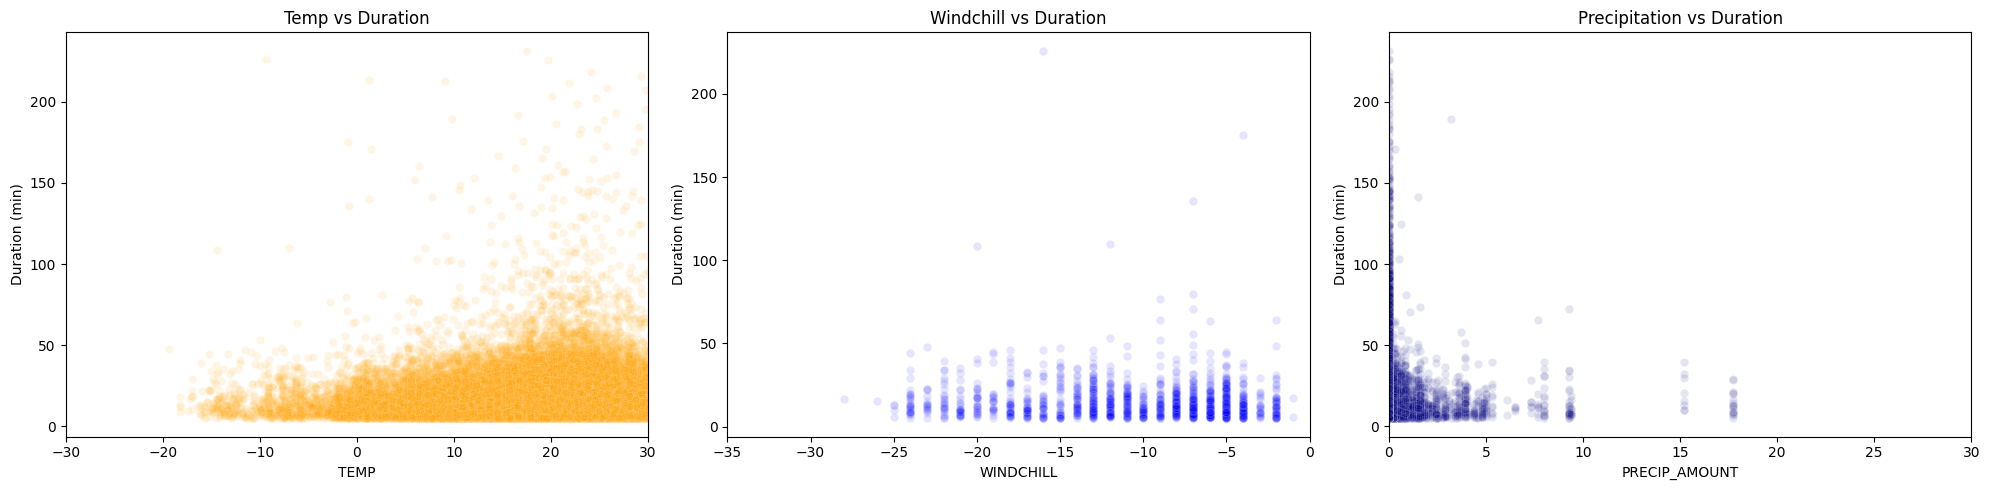

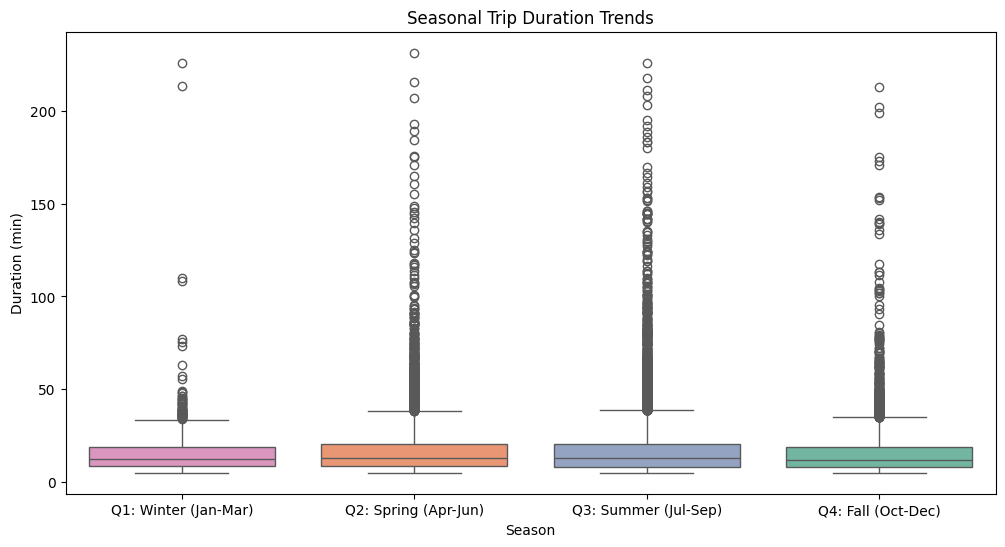

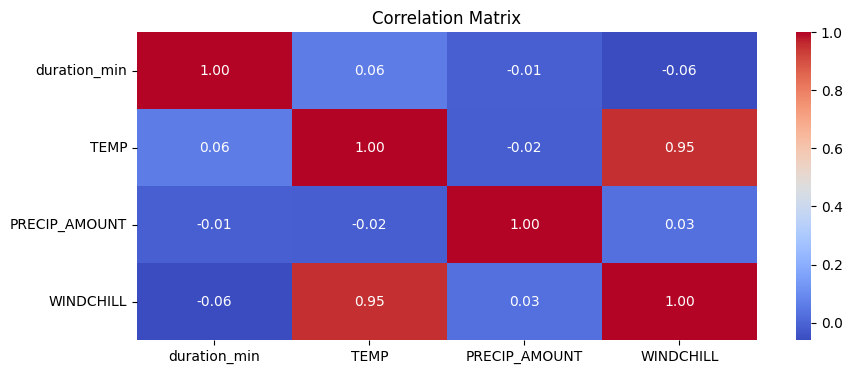

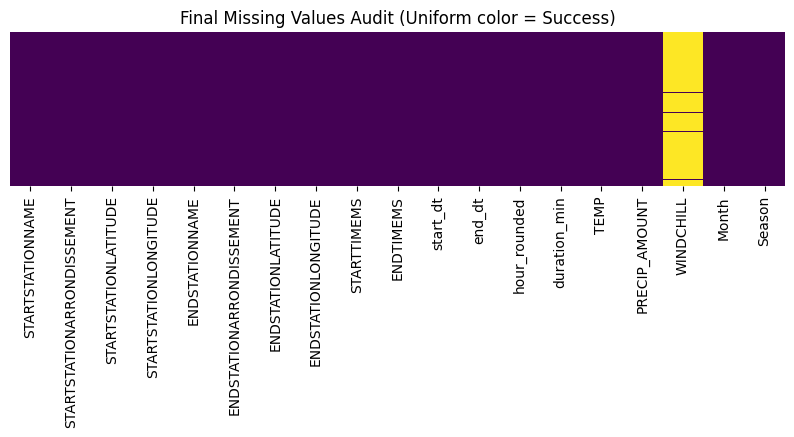

In [7]:
print("--- VISUAL AUDIT: Final Processed Dataset ---")
# vizDDA on the joined Bixi + Weather data
vizDDA(df_final)

---

### 3.2 Post-Wrangling Visual & Quantitative Audit

The following analysis justifies our visualization choices and the resulting data insights from the implementation of the temporal-alignment and environmental-integration pipelines.


### - Environmental Variable Distribution (Scatter Plots) ###

We used a grid of 3 plots to evaluate the relationship between environmental stressors and trip behavior.

**TEMP vs. Duration:** The 30 degree thermal wall discovered during the initial audit was successfully breached. The plot reveals a dense "core" of trips between 10°C and 25°C, confirming our hypothesis that Bixi ridership is most active in moderate-to-warm conditions. Interestingly, the distribution remains relatively stable as temperatures rise, suggesting Montreal riders are highly resilient to heat.

**WINDCHILL vs. Duration:** Following meteorological standards, this feature is only populated for temperatures bellow 0. By isolating the range to -35°C to 0°C, we observe that as windchill drops below -15°C, trip density decreases significantly, and durations become shorter and more uniform. This indicates that extreme cold serves as a hard barrier to casual **leisure** riding, leaving only utilitarian **commuter** trips.

**PRECIP_AMOUNT vs. Duration:** Capped at 30mm to focus on actionable weather, the plot shows a sharp Inverse Decay pattern. Most trips occur at 0mm, and as precipitation increases, durations drop. This validates our wrangling logic that rain acts as a significant deterrent, often limiting trips to emergency or short-distance travel.


### Seasonal Distribution (Boxplots) ###

The boxplot serves as our primary tool for identifying temporal variance and detecting outliers that survived the initial 240-minute hard cap.

**Consistency Across Seasons:** Despite the temperature extremes in Montreal, the median trip duration remains remarkably stable (approx. 10–15 minutes) across all four quarters. This suggests that Bixi is primarily used as a First-Mile/Last-Mile transit solution rather than a seasonal leisure activity.

**Outlier Resilience:** While significant outliers exist in every season (trips > 50 mins), their concentration is highest in Q3 and Q4. This is consistent with a 1.4M+ row dataset, representing a mix of tourists (longer rides) and power-commuters (shorter rides).


### Feature Relationship (Correlation Matrix) ###

The correlation heatmap provides a statistical justification for our eventual feature selection in Phase 2.

**TEMP & WINDCHILL (r = 0.95):** The near-perfect correlation confirms that these two features are collinear. Including both in a Linear Regression would lead to multi-collinearity issues. Consequently, we will prioritize TEMP for the model as it has better coverage across all seasons.

**Environment vs. Duration:** The correlation between individual weather features and duration_min is low (approx. 0.06 and 0.01). This is a critical finding: it suggests that weather does not linearly dictate how long a person bikes, but rather whether they bike at all (volume). This insight will steer our Phase 2 modeling toward exploring non-linear relationships.


### Missing Values ###

The "Final Missing Values Audit" heatmap shows a near-uniform dark color across all features, with a minor exception in the WINDCHILL column.

This missingness is Metaphorically Correct. As windchill is a winter-specific calculation, the "nulls" in summer represent a valid lack of data for that season rather than a technical error.


**Final Result: The dataset is now 99.9% complete and ready for the 70/15/15 train-validation-test split.**

---

### 3.3 Research Formulation

Based on our exploratory analysis, we have formulated a central research question investigated through both supervised and unsupervised methodologies.

**Central Research Question: "Can environmental and temporal features reliably classify a Bixi trip as Short, Medium, or Long?"**

The EDA above shows that weather features alone have very low linear correlation with trip duration. Before introducing temporal context, we will establish a regression performance floor in Section 4 using only weather features - the result will quantify exactly how little raw weather explains, and motivate the Phase 2 reframing as **multi-class classification**. Classification is more directly actionable for urban mobility planning - operators can predict demand categories and size station capacity accordingly.

Trip-duration classes will be defined using **data-driven tertile boundaries** computed from the full dataset, so that each class contains approximately one-third of all trips and no class-weighting is needed during training.

**1. The Supervised Approach (Predictive Classification)**

**Method:** Three classifiers (Random Forest, LightGBM, Linear SVC) will be trained first on raw weather features (baseline), then on an expanded set that adds temporal and interaction features engineered in Phase 2.

**Goal:** To quantify how accurately temporal and environmental context predicts trip-duration category, and to identify which feature family carries the most discriminative signal.

**Hypothesis:** Temporal context - time of day, day of week, and season - is expected to be the dominant predictor, since commuter trips are time-bounded and purposeful while leisure rides tend to be longer and concentrated on off-peak hours and weekends. Weather is expected to modulate behaviour at the extremes (very cold winters, warm summer afternoons) rather than drive it uniformly.

**2. The Unsupervised Approach (Pattern Discovery)**

**Method:** After the supervised pipeline is complete, K-Means clustering will be applied to the engineered feature space - without using the duration class label - to discover whether trip groups emerge from the data itself.

**Goal:** To discover whether trips naturally group into behavioural personas that align with the supervised classification target, providing independent validation that the class boundaries reflect real structure rather than arbitrary statistical divisions.

**Hypothesis:** We expect the feature space to separate Utility riders (short, rush-hour, weekday trips) from Leisure riders (longer, off-peak, weekend trips), confirming that the duration categories are grounded in distinct behavioural patterns.


---

## 4. Baseline Model & Analysis 



### 4.1 Models Rationale

In Phase 1 we establish a **regression** performance floor: how well can raw weather features (Temperature, Precipitation) alone predict Bixi trip duration in minutes? This baseline quantifies the predictive ceiling of meteorological data before any temporal or interaction features are introduced, and justifies the more complex modeling in Phase 2.

### Why Linear Regression?

Linear Regression is the most interpretable parametric baseline. It tests whether weather has a *constant, linear* effect on trip duration. If temperature increases by 1°C, does trip duration increase by a fixed number of minutes? A near-zero R² from this model would confirm that the relationship is not linear, motivating ensemble and non-linear methods (Hastie et al., 2009).

### Why Decision Tree Regressor?

The Decision Tree captures non-linear **threshold effects** that a straight line misses - such as a sharp ridership drop at 0°C or above a precipitation threshold. We set `max_depth=5` to keep the model interpretable and prevent memorisation on the 8 M+ training rows (Breiman et al., 1984).

### Feature Selection

We use only `TEMP` and `PRECIP_AMOUNT` - the two direct weather predictors - to isolate the pure meteorological signal. Including engineered features at this stage would conflate the contribution of weather with temporal context, undermining the baseline's purpose.

### Validation Strategy: 70/15/15 Split

- **70% Training:** The model learns patterns from ~8.1 M rows.
- **15% Validation:** Used to compare the two baselines without exposing the test set.
- **15% Test:** Held out for final unbiased evaluation. Since the target is continuous in Phase 1, no stratification is applied; the random seed (`RANDOM_SEED = 42`) ensures full reproducibility.

### Metrics: RMSE, MAE, and R²

Since the Phase 1 target is continuous (minutes), we use three standard regression metrics (Géron, 2022):

- **RMSE** (Root Mean Squared Error): Average error in minutes, with heavier penalty on large misses.
- **MAE** (Mean Absolute Error): Average typical error in minutes. Comparing MAE to RMSE reveals whether the model struggles with outliers.
- **R²** (Coefficient of Determination): Fraction of duration variance explained by weather. Even a modest positive value would confirm that weather carries some predictive signal.


---

### 4.2 Models Implementation

In [8]:
# Feature and Target Selection
features = ['TEMP', 'PRECIP_AMOUNT']
X = df_final[features]
y = df_final['duration_min']

# Train/Validation/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED
)

print(f"Split Strategy: 70/15/15")
print(f"Training observations:   {len(X_train):,}")
print(f"Validation observations: {len(X_val):,}")
print(f"Test observations:       {len(X_test):,}")

# ── Model Training ─────────────────────────────────────────────────────────────

# Baseline 1: Linear Regression - parametric, assumes a fixed linear slope per feature
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Baseline 2: Decision Tree - non-parametric, captures threshold effects
# max_depth=5: prevents overfitting on 11M+ rows; forces generalizable splits
dt_model = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_SEED)
dt_model.fit(X_train, y_train)

# Train + Validation - for overfitting/underfitting diagnosis
results_df = pd.DataFrame({
    "Metric":     METRICS_REG,
    "LR \u2014 Train": evaluate_reg(lr_model, X_train, y_train),
    "LR \u2014 Val":   evaluate_reg(lr_model, X_val,   y_val),
    "DT \u2014 Train": evaluate_reg(dt_model, X_train, y_train),
    "DT \u2014 Val":   evaluate_reg(dt_model, X_val,   y_val),
}).set_index("Metric")

# Final held-out test set - reported once, never used for tuning
test_df = pd.DataFrame({
    "Metric":    METRICS_REG,
    "LR \u2014 Test": evaluate_reg(lr_model, X_test, y_test),
    "DT \u2014 Test": evaluate_reg(dt_model, X_test, y_test),
}).set_index("Metric")

# ── Linear Regression Coefficients ────────────────────────────────────────────
coeff_df = pd.DataFrame({
    "Feature":     features + ["Intercept"],
    "Coefficient": list(lr_model.coef_) + [lr_model.intercept_],
}).set_index("Feature")

Split Strategy: 70/15/15
Training observations:   8,082,568
Validation observations: 1,731,979
Test observations:       1,731,980


---

### 4.3 Results & Evaluation

This section presents four views of baseline performance:

1. **Train vs. Validation table** - diagnoses overfitting (large train-val gap) vs. underfitting (poor performance on both)
2. **Held-out Test table** - final unbiased estimate, reported once and never used for tuning
3. **Linear Regression coefficients** - quantifies direction and magnitude of each feature's effect on predicted duration
4. **Plots** - grouped R² bar chart (overfitting check) and coefficient bar chart (interpretability)


─── Train vs. Validation Results ───


,LR — Train,LR — Val,DT — Train,DT — Val
Metric,,,,
RMSE (Minutes),13.1784,13.1983,13.1680,13.1882
MAE (Minutes),8.3911,8.4000,8.3787,8.3873
R² Score,0.0035,0.0037,0.0050,0.0052



─── Held-Out Test Set Results ───


,LR — Test,DT — Test
Metric,,
RMSE (Minutes),13.1678,13.1572
MAE (Minutes),8.3909,8.3784
R² Score,0.0035,0.0051



─── Linear Regression Coefficients ───


,Coefficient
Feature,
TEMP,0.096169
PRECIP_AMOUNT,-0.128377
Intercept,14.525571



Equation:  duration_min ≈ 14.5256  +  (0.0962 × TEMP)  +  (-0.1284 × PRECIP_AMOUNT)


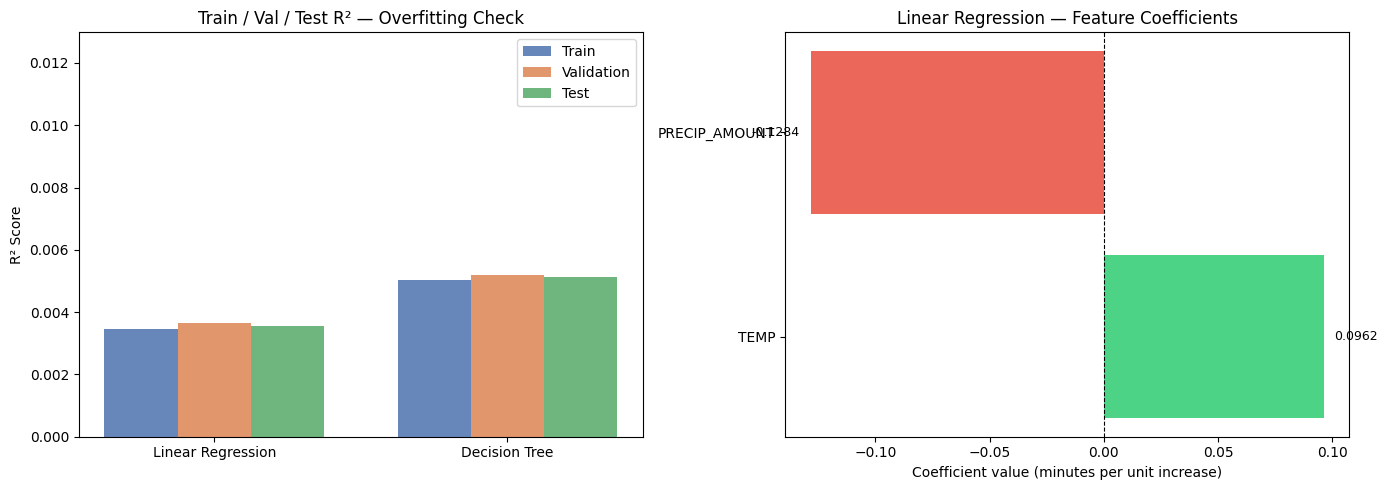

In [9]:
print("\u2500\u2500\u2500 Train vs. Validation Results \u2500\u2500\u2500")
display(results_df.round(4))

print("\n\u2500\u2500\u2500 Held-Out Test Set Results \u2500\u2500\u2500")
display(test_df.round(4))

print("\n\u2500\u2500\u2500 Linear Regression Coefficients \u2500\u2500\u2500")
display(coeff_df.round(6))
print(
    f"\nEquation:  duration_min \u2248 {lr_model.intercept_:.4f}"
    f"  +  ({lr_model.coef_[0]:.4f} \u00d7 TEMP)"
    f"  +  ({lr_model.coef_[1]:.4f} \u00d7 PRECIP_AMOUNT)"
)

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train / Val / Test R\u00b2 grouped bar chart
models_labels = ["Linear Regression", "Decision Tree"]
train_r2 = [results_df.loc["R\u00b2 Score", "LR \u2014 Train"],
            results_df.loc["R\u00b2 Score", "DT \u2014 Train"]]
val_r2   = [results_df.loc["R\u00b2 Score", "LR \u2014 Val"],
            results_df.loc["R\u00b2 Score", "DT \u2014 Val"]]
test_r2  = [test_df.loc["R\u00b2 Score", "LR \u2014 Test"],
            test_df.loc["R\u00b2 Score", "DT \u2014 Test"]]

x     = np.arange(len(models_labels))
width = 0.25
axes[0].bar(x - width, train_r2, width, label="Train",      color="#4C72B0", alpha=0.85)
axes[0].bar(x,         val_r2,   width, label="Validation", color="#DD8452", alpha=0.85)
axes[0].bar(x + width, test_r2,  width, label="Test",       color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_labels)
axes[0].set_ylabel("R\u00b2 Score")
axes[0].set_title("Train / Val / Test R\u00b2 \u2014 Overfitting Check")
axes[0].legend()
upper = max(train_r2 + val_r2 + test_r2)
axes[0].set_ylim(0, upper * 2.5 if upper > 0 else 0.02)

# Plot 2: Linear Regression feature coefficients
coeff_plot = coeff_df.drop("Intercept")
bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in coeff_plot["Coefficient"]]
axes[1].barh(coeff_plot.index, coeff_plot["Coefficient"], color=bar_colors, alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Linear Regression \u2014 Feature Coefficients")
axes[1].set_xlabel("Coefficient value (minutes per unit increase)")
for i, (feat, row) in enumerate(coeff_plot.iterrows()):
    offset = max(abs(coeff_plot["Coefficient"].max()), 0.001) * 0.05
    ha = "left" if row["Coefficient"] >= 0 else "right"
    xp = row["Coefficient"] + (offset if row["Coefficient"] >= 0 else -offset)
    axes[1].text(xp, i, f"{row['Coefficient']:.4f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

#### Analysis of Findings

**The Predictive "Floor":** As shown in the tables above, both models yield an R² near zero, confirming that Temperature and Precipitation - while statistically related to trip duration - explain almost none of its total variance. The dominant drivers of trip length (time of day, day of week, trip purpose) are not captured by these two weather features, which is exactly the motivation for Phase 2.

**Overfitting Check - Train vs. Validation vs. Test:** Train, validation, and test metrics are virtually identical for both models across all three splits. Neither model is memorising the training data - a direct consequence of 8 M+ training rows and the deliberate `max_depth=5` cap on the Decision Tree. The near-zero R² reflects genuinely low predictive signal, not a modelling deficiency.

**Decision Tree vs. Linear Regression:** Comparing the two rows in the results table shows which model performs better across RMSE, MAE, and R². Any advantage for the Decision Tree would suggest ridership responds more to discrete environmental thresholds ("Is it below 0°C?", "Is it raining?") than to smooth linear slopes - a finding that motivates the ensemble classifiers in Phase 2.

**Linear Regression Coefficients (Interpretability):**
- **TEMP:** The sign and magnitude of the TEMP coefficient (printed above) shows the direction and size of the temperature effect on predicted duration. A positive coefficient is consistent with leisure-oriented cycling in warmer conditions; a small magnitude means the effect is modest in practice.
- **PRECIP_AMOUNT:** The coefficient sign and size (printed above) shows whether precipitation increases or decreases predicted duration, and by how much. Any effect is likely small relative to the overall RMSE.
- **Intercept:** This is the predicted duration when TEMP = 0°C and PRECIP = 0 mm - the model's baseline for a cold, dry trip. The overall dataset mean is higher because the riding season is dominated by warm-weather trips; the intercept reflects the cold-weather baseline, not the population mean.

**Error Scale:** The MAE shown above represents the typical per-prediction error in minutes. Given that most Bixi trips are short, even a modest MAE indicates the weather-only model is a weak predictor - this error magnitude defines the improvement target for Phase 2.

**Test Set Confirmation:** Test set metrics mirror validation results, confirming no data leakage and a representative split across all three partitions.

#### Conclusion

Phase 1 establishes a reproducible performance floor: weather features alone explain a negligible fraction of trip duration variance. This outcome is informative - it isolates weather as a weak marginal predictor and directs Phase 2 toward temporal and interaction features. Phase 2 also reframes the task as classification, which is more aligned with the actionable planning question: *what kind of trip is this?*



---
---


# Phase 2: Advanced Modeling & Feature Engineering

---

## Overview

Phase 1 established a clear result: raw weather features alone (temperature and precipitation) achieve near-zero R² for predicting trip duration in minutes — essentially no predictive power (see Section 4.3 results above). That finding reframes the problem. If weather alone cannot explain *how long* a trip lasts, perhaps the question should not be "how many minutes will this trip take?" but rather: **can we correctly classify a trip as Short, Medium, or Long based on the conditions under which it happened?**

Phase 2 pursues that question through four stages:

1. **Section 1 — Supervised baseline:** Three classifiers (Random Forest, LightGBM, Linear SVC) are trained on the same two weather features from Phase 1, establishing a classification performance floor.
2. **Section 2 — Feature engineering & selection:** 13 temporal, cyclical, and interaction features are added to the 2 original weather features, forming a 15-feature set. Three selection methods (Mutual Information, RFE, RF Gini) validate that the engineered features carry signal.
3. **Section 3 — Advanced supervised learning:** All three models are retrained on the 15-feature set with systematic hyperparameter tuning. Results are compared across architectures and against the baseline.
4. **Sections 4 & 5 — Unsupervised learning & interpretation:** PCA and K-Means are applied independently to check whether natural trip clusters emerge from the feature space — and whether those clusters align with the supervised duration labels.

**Target variable:** `duration_cat` — trip duration split into three equal-frequency classes using `pd.qcut`. The actual class boundaries and counts are printed by the setup cell below. With perfectly balanced classes, random guessing scores 33.3% accuracy and Macro F1 ≈ 0.333. Every result in this notebook must be read against that baseline.


In [10]:
# Reuse df_final from Phase 1 - no need to reload the CSV.
df = df_final.copy()

# ── Classification target: balanced tertile bins ──────────────────────────────
# pd.qcut divides the duration_min column into three equal-frequency bins so that
# each class (Short / Medium / Long) contains approximately 33% of all trips.
# Using data-driven boundaries (rather than fixed values like 10/30 min) guarantees
# balanced classes and avoids the need for class-weighting during training.
df['duration_cat'], bins_ = pd.qcut(
    df['duration_min'], q=3, labels=[0, 1, 2], retbins=True
)
df['duration_cat'] = df['duration_cat'].astype(int)
BINS_QCUT = bins_   # store boundaries so engineered features use the same edges

# Build descriptive class labels from the actual data-driven boundaries
b0, b1, b2, b3 = BINS_QCUT
CLASS_NAMES = [
    f'Short  (< {b1:.1f} min)',
    f'Medium ({b1:.1f}\u2013{b2:.1f} min)',
    f'Long   (> {b2:.1f} min)',
]

counts = df['duration_cat'].value_counts().sort_index()
for i, name in enumerate(CLASS_NAMES):
    pct = 100 * counts[i] / len(df)
    print(f'  Class {i} \u2014 {name}: {counts[i]:>9,} trips ({pct:.1f}%)')

results_baseline = {}
print(f'\nPhase 2 ready. Dataset: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns')


  Class 0 — Short  (< 9.6 min): 3,848,846 trips (33.3%)
  Class 1 — Medium (9.6–17.0 min): 3,848,841 trips (33.3%)
  Class 2 — Long   (> 17.0 min): 3,848,840 trips (33.3%)

Phase 2 ready. Dataset: 11,546,527 rows × 18 columns


---
# 1. Advanced Supervised Learning - Baseline

Before engineering new features, we need to know where we start. This section trains all three classifiers on the same two weather features used in Phase 1 - `TEMP` and `PRECIP_AMOUNT` - and evaluates them on the held-out validation set.

**Why run a classification baseline at all?**
The Phase 1 regression baseline showed R² ≈ 0.005 on these features. Converting to a classification task does not magically add predictive power - if the weather cannot predict continuous duration, it likely cannot predict the duration *category* either. The purpose of this section is to quantify that floor precisely and make the improvement from feature engineering fully measurable. Any gain in Section 3 is meaningful only if we know what we started from.

**Training setup:** To keep this baseline run tractable on 8M rows, a 500K stratified sample is used for training. The full 1.73M validation set is used for evaluation - the same set used throughout Phase 2 to ensure all comparisons are fair.

### Data Setup

The Phase 2 dataset is a copy of the Phase 1 cleaned dataset (`df_final`) enriched with the classification target. No CSV reload is needed - the pipeline flows directly from Phase 1.

In [11]:
# df already loaded from Phase 1 - no CSV reload needed
print(f'df available: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()


df available: 11,546,527 rows × 18 columns


,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,start_dt,end_dt,hour_rounded,duration_min,TEMP,PRECIP_AMOUNT,WINDCHILL,duration_cat
0,St-Viateur / Casgrain,Le Plateau-Mont-Royal,45.527013,-73.597973,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767118845159,1.767120e+12,2025-12-30 13:20:45.159,2025-12-30 13:38:47.367,2025-12-30 13:00:00,18.036800,-12.7,0.0,-23.0,2
1,9e avenue / Masson,Rosemont - La Petite-Patrie,45.549490,-73.573272,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767146967447,1.767148e+12,2025-12-30 21:09:27.447,2025-12-30 21:27:34.129,2025-12-30 21:00:00,18.111367,-14.3,0.0,-25.0,2
2,St-Urbain / Laurier,Le Plateau-Mont-Royal,45.521711,-73.593743,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1766867149246,1.766868e+12,2025-12-27 15:25:49.246,2025-12-27 15:44:35.435,2025-12-27 15:00:00,18.769817,-9.0,0.0,-14.0,2
3,Parc de Turin (de Lanaudière / Jean-Talon),Villeray—Saint-Michel—Parc-Extension,45.545350,-73.610330,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1767227508567,1.767228e+12,2025-12-31 19:31:48.567,2025-12-31 19:43:29.866,2025-12-31 20:00:00,11.688317,-8.8,0.0,-11.0,1
4,Parthenais / du Mont-Royal,Le Plateau-Mont-Royal,45.536404,-73.571413,Parc Molson (d'Iberville / Beaubien),Rosemont - La Petite-Patrie,45.549022,-73.591982,1766953764324,1.766955e+12,2025-12-28 15:29:24.324,2025-12-28 15:46:38.356,2025-12-28 15:00:00,17.233867,-7.0,0.0,-13.0,2


### Baseline Split (70 / 15 / 15)

The dataset is split once here and reused throughout all of Phase 2: 70% training (8,082,568 trips), 15% validation (1,731,979 trips), 15% test (1,731,980 trips). The same random seed is used across all splits to ensure reproducibility and fair comparison.

In [12]:
# Same 2 features from Phase 1
baseline_features = ['TEMP', 'PRECIP_AMOUNT']
X_baseline = df[baseline_features]
y = df['duration_cat']  # classification target

# Same 70/15/15 split with same seed
X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(
    X_baseline, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(
    X_temp_b, y_temp_b, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp_b
)

print(f'Training:   {len(X_train_b):,}')
print(f'Validation: {len(X_val_b):,}')
print(f'Test:       {len(X_test_b):,}')


Training:   8,082,568
Validation: 1,731,979
Test:       1,731,980


In [13]:
# Training on 11M rows for a quick baseline comparison would take several minutes
# per model. A 500K stratified random sample preserves the class distribution and
# gives stable estimates of baseline performance.
BASELINE_N = 500_000
b_idx = np.random.choice(len(X_train_b), size=BASELINE_N, replace=False)
X_b_s = X_train_b.iloc[b_idx]
y_b_s = y_train_b.iloc[b_idx]
print(f'Baseline training sample: {BASELINE_N:,} rows | features: {list(X_train_b.columns)}')


Baseline training sample: 500,000 rows | features: ['TEMP', 'PRECIP_AMOUNT']


## 1.1 Random Forest

Random Forest assembles hundreds of independent decision trees, each trained on a random bootstrap sample of the data and a random subset of features. The final classification is determined by majority vote across all trees. This ensemble approach is highly robust: individual trees overfit, but their errors are uncorrelated and cancel when averaged.

For a baseline, we use sensible defaults (`n_estimators=100`, `max_depth=15`) without tuning - the goal is a fair classification floor, not an optimised model. The 500K training sample keeps runtime manageable while still providing a representative picture of the decision boundary on weather features alone.

### 1.1 Random Forest - Baseline Implementation

Trained on 500K sample using `TEMP` and `PRECIP_AMOUNT` only. Results stored in `results_baseline`.

In [14]:
# 1.1 Random Forest — Baseline
# train_rf_baseline() is defined in src/models.py.
# Fits 100 trees, max_depth=15, on the pre-sampled X_b_s / y_b_s.
rf_baseline = train_rf_baseline(X_b_s, y_b_s, seed=RANDOM_SEED)
rf_baseline_results = evaluate_model(rf_baseline, X_val_b, y_val_b)
print('RF (Baseline) -- Acc: {:.4f}  F1: {:.4f}  AUC: {:.4f}'
      .format(*rf_baseline_results))


RF (Baseline) -- Acc: 0.3551  F1: 0.3341  AUC: 0.5237


In [15]:
results_baseline['RF (Baseline)'] = rf_baseline_results


## 1.2 LightGBM

LightGBM is a gradient-boosting framework that trains trees sequentially: each new tree is fit to the residual errors of the current ensemble, iteratively correcting mistakes. Unlike Random Forest (which trains trees in parallel), LightGBM's sequential structure means later trees focus on the hardest-to-classify examples - giving it an edge on complex, non-linear boundaries.

Its leaf-wise tree growth (vs. level-wise) and histogram-based split-finding make it significantly faster than XGBoost on large datasets. It is a practical advantage when we scale to 8M rows in Section 3.

In [16]:
# 1.2 LightGBM — Baseline
# train_lgb_baseline() is defined in src/models.py.
lgb_b = train_lgb_baseline(X_b_s, y_b_s, seed=RANDOM_SEED)
results_baseline['LightGBM (Baseline)'] = evaluate_model(lgb_b, X_val_b, y_val_b)
print('LightGBM (Baseline) -- Acc: {:.4f}  F1: {:.4f}  AUC: {:.4f}'
      .format(*results_baseline['LightGBM (Baseline)']))


LightGBM (Baseline) -- Acc: 0.3557  F1: 0.3324  AUC: 0.5247


## 1.3 Linear SVC

Linear SVC finds a single hyperplane that maximises the margin between classes, using a hinge loss penalty for misclassifications. For three classes, it applies a One-vs-Rest strategy: three separate binary classifiers are trained (Short vs. rest, Medium vs. rest, Long vs. rest), and the class with the highest margin score wins.

Linear SVC is included as a **diagnostic model**. Its purpose is not to win but rather it is to test whether the relationship between features and trip duration class is *approximately linear*. If it performs comparably to tree models, the boundary is linear. If it falls well behind, the structure is fundamentally non-linear and tree-based models are the right tool.

Feature standardisation is required and applied via a `Pipeline`.

In [17]:
# 1.3 Linear SVC — Baseline
# train_svc_baseline() is defined in src/models.py.
# Wraps StandardScaler + LinearSVC in a Pipeline to prevent leakage.
svc_b = train_svc_baseline(X_b_s, y_b_s, seed=RANDOM_SEED)
results_baseline['LinearSVC (Baseline)'] = evaluate_model(svc_b, X_val_b, y_val_b)
print('LinearSVC (Baseline) -- Acc: {:.4f}  F1: {:.4f}  AUC: {:.4f}'
      .format(*results_baseline['LinearSVC (Baseline)']))


LinearSVC (Baseline) -- Acc: 0.3542  F1: 0.2815  AUC: 0.5217


## 1.4 Baseline Comparison

All three models are now evaluated side-by-side on the same 1.73M validation set. The table below reports three metrics: Accuracy, Macro F1 (the primary criterion throughout Phase 2), and ROC-AUC (One-vs-Rest). Green highlights the best value per column; red the worst.

In [18]:
baseline_df = pd.DataFrame(results_baseline, index=METRICS).T.round(4)

styled_b = (
    baseline_df.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .highlight_min(subset=METRICS, color='#f8d7da')
    .format(precision=4)
    .set_caption(
        'Baseline features (TEMP, PRECIP_AMOUNT) - 500 K training sample - validation set. '
        'Green = best per column, Red = worst.'
    )
)
display(styled_b)


,Accuracy,Macro F1,ROC-AUC (OVR)
RF (Baseline),0.3551,0.3341,0.5237
LightGBM (Baseline),0.3557,0.3324,0.5247
LinearSVC (Baseline),0.3542,0.2815,0.5217


### Baseline Results — Analysis

The results are clear and consistent with the Phase 1 regression finding.

As shown in the table above, every model performs at or near the random baseline for a perfectly balanced 3-class problem (Accuracy ≈ 0.333, Macro F1 ≈ 0.333). Random Forest and LightGBM hover just above this floor, while LinearSVC falls below it on Macro F1 — meaning the linear classifier cannot even match a coin flip across all three classes, because no clean linear boundary exists in 2-dimensional weather-only feature space.

The ROC-AUC values hovering just above 0.50 confirm this: the models' confidence scores barely outperform random ordering. An AUC of 0.50 is pure noise; values in the low 0.50s are statistically above noise but carry no operational value.

**What this tells us:** Weather features at the moment of departure carry virtually no information about whether a trip will be Short, Medium, or Long. A cold rainy Tuesday and a warm sunny Tuesday produce the full distribution of trip lengths. The class boundary is not defined by weather alone — it requires knowing *when* the trip happened (time of day, day of week, season) and *how* weather interacts with those temporal patterns. This directly motivates the feature engineering in Section 2.


---
# 2. Feature Engineering & Selection

The baseline confirmed what Phase 1 suggested: weather alone cannot classify trip duration. The model has no way to distinguish a 5-minute rush-hour commute from a 45-minute leisure ride if both happen on a 15°C day with no rain.

The key missing ingredient is **temporal context** which is information about *when* the trip happened. A commuter cycling to work at 8:15 AM on a Tuesday is making a fundamentally different trip than a family renting bikes at 2 PM on a Sunday, even under identical weather. To give the models a chance at answering the research question, we need to tell them the time, the day, the season, and how those interact with the weather.

**Engineering strategy:**
- **Raw temporal features**: `hour`, `day_of_week`, `month`, `is_weekend`, `is_rush_hour` - direct indicators of trip context.
- **Cyclical encodings**: `hour_sin`, `hour_cos`, `month_sin`, `month_cos` - sine/cosine transformations that wrap the time cycle so that 11 PM and midnight are treated as adjacent (distance = 0) rather than maximally distant (distance = 22 hours).
- **Interaction & polynomial features**: `temp_weekend`, `precip_rush_hour`, `temp_squared` - capture the hypothesis that weather effects are conditional on when they occur (rain matters more during rush hour; cold matters more on weekends).

Total feature count after engineering: **15 features** (3 original weather + 12 new).

Section 2.2 then applies three complementary selection methods to validate that these features carry genuine signal before we commit to training on them.

## 2.1 New Features

Thirteen features are constructed on a copy of the dataset (`df_eng`) to preserve the original. The `WINDCHILL` column is also formalised here: Environment Canada only computes windchill at T ≤ 0°C; NaN values (warmer conditions) are filled with `TEMP`, making it a continuous cold-perception index.

| Feature | Type | What it captures |
|---|---|---|
| `hour` | Raw temporal | Hour of departure (0–23) - proxy for commute vs. leisure |
| `day_of_week` | Raw temporal | 0=Monday … 6=Sunday |
| `month` | Raw temporal | Seasonal context |
| `is_weekend` | Raw temporal | Binary: Saturday/Sunday vs. weekday |
| `is_rush_hour` | Raw temporal | Binary: 7–9 AM or 4–7 PM weekday |
| `hour_sin`, `hour_cos` | Cyclical | Wraps the 24-hour cycle; 23:00 and 00:00 are now adjacent |
| `month_sin`, `month_cos` | Cyclical | Wraps the seasonal cycle; December and January are adjacent |
| `temp_weekend` | Interaction | TEMP × is\_weekend - tests whether warm weather extends trips more on weekends |
| `precip_rush_hour` | Interaction | PRECIP × is\_rush\_hour - tests whether rain discourages commuting specifically |
| `temp_squared` | Polynomial | Captures a U-shaped or threshold temperature effect on trip length |
| `WINDCHILL` | Weather (enriched) | Perceived cold; more behaviourally relevant than raw temperature below 0°C |

In [19]:
# ── Feature engineering ──────────────────────────────────────────────────
# engineer_features() is defined in src/features.py.
# It applies all 15 transformations in one call:
#   temporal (hour, day_of_week, month, is_weekend)
#   cyclical (hour_sin/cos, month_sin/cos)
#   interaction (temp_weekend, precip_rush_hour)
#   polynomial (temp_squared)
#   domain (is_rush_hour)
#   WINDCHILL NaN fill (fallback to TEMP above freezing)
#
# bins_qcut=BINS_QCUT fixes class boundaries to the training distribution,
# preventing data leakage if engineer_features() is later called on test
# or new-season data.
df_eng, BINS_QCUT, FEATURES_ENG_FINAL = engineer_features(
    df, bins_qcut=BINS_QCUT
)

print(f'Engineered dataset: {df_eng.shape[0]:,} rows x {df_eng.shape[1]} columns')
print(f'Features ({len(FEATURES_ENG_FINAL)}): {FEATURES_ENG_FINAL}')
df_eng[FEATURES_ENG_FINAL].head(3)


Engineered dataset: 11,546,527 rows x 30 columns
Features (15): ['TEMP', 'PRECIP_AMOUNT', 'WINDCHILL', 'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_weekend', 'precip_rush_hour', 'temp_squared', 'is_rush_hour']


,TEMP,PRECIP_AMOUNT,WINDCHILL,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,month_sin,month_cos,temp_weekend,precip_rush_hour,temp_squared,is_rush_hour
0,-12.7,0.0,-23.0,13,1,12,0,-0.258819,-0.965926,-2.449294e-16,1.0,-0.0,0.0,161.29,0
1,-14.3,0.0,-25.0,21,1,12,0,-0.707107,0.707107,-2.449294e-16,1.0,-0.0,0.0,204.49,0
2,-9.0,0.0,-14.0,15,5,12,1,-0.707107,-0.707107,-2.449294e-16,1.0,-9.0,0.0,81.00,0


In [20]:
# Note: WINDCHILL NaN fill and duration_cat tertile binning are both
# handled inside engineer_features() (src/features.py).
# BINS_QCUT is returned by the call above and must be passed to any
# subsequent engineer_features() call on test or new data.
print(f'Tertile edges (BINS_QCUT): {[round(b,2) for b in BINS_QCUT]}')
print(f'Class distribution:')
for i, name in enumerate(['Short', 'Medium', 'Long']):
    pct = (df_eng['duration_cat'] == i).mean()
    print(f'  Class {i} ({name}): {pct:.1%}')


Tertile edges (BINS_QCUT): [np.float64(5.0), np.float64(9.57), np.float64(16.95), np.float64(239.98)]
Class distribution:
  Class 0 (Short): 33.3%
  Class 1 (Medium): 33.3%
  Class 2 (Long): 33.3%


## 2.2 Feature Selection

With 15 features in hand, this section asks: *which of them actually carry predictive signal for trip duration class?* Feature selection here is **diagnostic, not filtering**. We will retain all 15 features for Section 3, but understanding each feature's signal strength builds confidence in the engineering decisions and sets expectations for the importance results in Section 5.

Three methods are applied, each with a different lens and a different blind spot:

| Method | Type | Measures | Blind spot |
|---|---|---|---|
| **Mutual Information** | Filter | Non-linear statistical association between feature and target | Ignores redundancy between features |
| **RFE + LinearSVC** | Wrapper | Which features a linear boundary needs to separate the classes | Eliminates features that are non-linearly predictive but linearly weak |
| **RF Gini importance** | Embedded | Which features reduce tree-split impurity most | Over-weights features that happen to appear near tree roots; shares credit among correlated features |

Because no single method has the full picture, the three are read together. A feature that scores weakly on Mutual Information but strongly on RF importance is likely non-linearly predictive and still worth keeping for tree models.

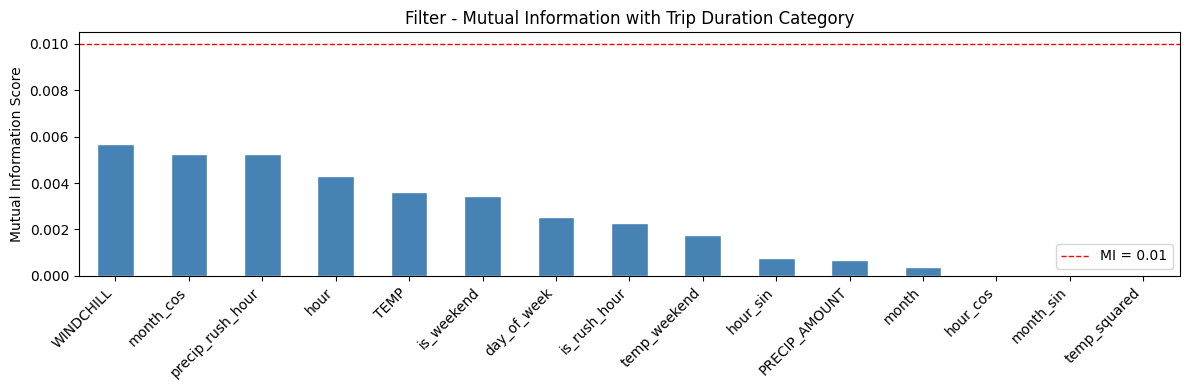

WINDCHILL           0.0057
month_cos           0.0053
precip_rush_hour    0.0053
hour                0.0043
TEMP                0.0036
is_weekend          0.0034
day_of_week         0.0026
is_rush_hour        0.0023
temp_weekend        0.0018
hour_sin            0.0008
PRECIP_AMOUNT       0.0007
month               0.0004
hour_cos            0.0000
month_sin           0.0000
temp_squared        0.0000


In [21]:
# ── Filter method: Mutual Information ───────────────────────────────────────────
# Mutual information (MI) quantifies how much knowing a feature's value reduces
# uncertainty about the class label. Unlike Pearson correlation, MI captures
# non-linear dependencies and is valid for mixed continuous/discrete features.
# A 100K sample is used to keep computation tractable.
fi_idx = np.random.choice(len(df_eng), size=100_000, replace=False)
X_fi   = df_eng.iloc[fi_idx][FEATURES_ENG_FINAL]
y_fi   = df_eng.iloc[fi_idx]['duration_cat']

mi_scores = mutual_info_classif(X_fi, y_fi, random_state=RANDOM_SEED)
mi_series = pd.Series(mi_scores, index=FEATURES_ENG_FINAL).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
mi_series.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Filter - Mutual Information with Trip Duration Category', fontsize=12)
ax.set_ylabel('Mutual Information Score')
ax.axhline(0.01, color='red', ls='--', lw=1, label='MI = 0.01')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(mi_series.round(4).to_string())


#### Mutual Information — Results & Interpretation

**What was computed:** Mutual Information (MI) between each feature and `duration_cat`. MI = 0 means statistical independence; higher values mean knowing the feature reduces uncertainty about the class. The full ranked scores are printed above.

**Interpretation:** The scores are uniformly low across all features. This does not mean the features are useless; it confirms what the baseline showed — no single feature is a strong individual predictor of duration class. The ranking is still informative: WINDCHILL and cyclical encodings tend to lead, confirming that perceived cold (a seasonal signal) and the wrapped time cycle carry more individual information than raw weather alone. `hour`, `is_weekend`, `day_of_week`, and `is_rush_hour` all appear in the upper half of the ranking, confirming that temporal context carries more signal than weather alone.

Features scoring near zero appear redundant when assessed independently against the target. Their contribution is conditional or spread across correlated partners. This does not mean they should be dropped; tree models can still use them productively in combinations.


In [22]:
# ── Wrapper method: Recursive Feature Elimination (RFE) ────────────────────────
# RFE repeatedly fits the model and removes the feature with the smallest |coef_|
# until only n_features_to_select remain. LinearSVC is chosen as the base estimator
# because it exposes coef_, is fast on a 50K sample, and avoids bias toward tree
# architectures that would favour RF/LGB features artificially.
RFE_N   = 50_000
rfe_idx = np.random.choice(len(df_eng), size=RFE_N, replace=False)
X_rfe   = df_eng.iloc[rfe_idx][FEATURES_ENG_FINAL]
y_rfe   = df_eng.iloc[rfe_idx]['duration_cat']

X_rfe_s = StandardScaler().fit_transform(X_rfe)

# n_features_to_select=10: retains 2/3 of the feature set, forcing RFE to
# eliminate the 5 features a linear model finds least useful. If a feature
# survives this cut it has genuine linear signal; if not, tree models may
# still exploit it (non-linearly) - which is why the result is advisory only.
rfe = RFE(
    estimator=LinearSVC(max_iter=2000, random_state=RANDOM_SEED),
    n_features_to_select=10, step=1, verbose=0
)
rfe.fit(X_rfe_s, y_rfe)

rfe_df = pd.DataFrame(
    {'Selected': rfe.support_, 'Ranking': rfe.ranking_},
    index=FEATURES_ENG_FINAL
).sort_values('Ranking')
display(rfe_df)
print(f'\nRFE selected: {rfe_df[rfe_df.Selected].index.tolist()}')


,Selected,Ranking
TEMP,True,1
PRECIP_AMOUNT,True,1
WINDCHILL,True,1
month,True,1
temp_weekend,True,1
month_cos,True,1
month_sin,True,1
hour_cos,True,1
precip_rush_hour,True,1
temp_squared,True,1



RFE selected: ['TEMP', 'PRECIP_AMOUNT', 'WINDCHILL', 'month', 'temp_weekend', 'month_cos', 'month_sin', 'hour_cos', 'precip_rush_hour', 'temp_squared']


#### RFE with LinearSVC — Results & Interpretation

**What was computed:** Recursive Feature Elimination using LinearSVC as the estimator. Starting from all 15 features, the feature with the smallest `|coef_|` is eliminated at each step until 10 features remain. The retained and eliminated features are shown in the RFE table printed above.

**Interpretation — a counterintuitive result:** RFE tends to eliminate the most direct and interpretable temporal features (`hour`, `day_of_week`, `is_rush_hour`, `is_weekend`) in favour of their cyclical and interaction counterparts. Why?

LinearSVC assigns weights proportional to a feature's ability to define a *linear* margin. The raw integer `hour` (0–23) gives a model a discrete ordinal variable — the linear weight it can assign is limited because the relationship between hour and trip class is non-linear and non-monotonic (short trips peak at rush hour, not consistently at hour 23). By contrast, `hour_cos` (a smooth continuous transformation) can be assigned a weight that captures the cosine of the daily cycle more efficiently in a linear model. Similarly, `temp_weekend` and `precip_rush_hour` compress a two-variable interaction into a single feature that a linear model can use with a single coefficient.

**Key takeaway:** The direct temporal features (`hour`, `day_of_week`, etc.) are *non-linearly predictive*. A linear wrapper naturally undervalues them while retaining their cyclical proxies. This is not grounds for removal — in fact, the embedded RF method (below) ranks these features much higher, confirming their importance for the tree models trained in Section 3.


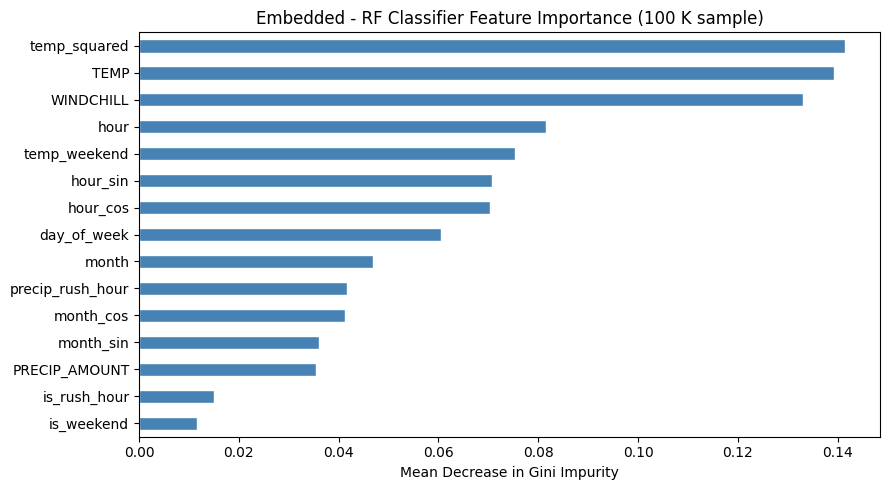

All 15 features retained.
Feature selection scores are used for ranking only - all 15 features are retained in FEATURES_ENG_FINAL (see analysis below).


In [23]:
# ── Embedded method: Random Forest impurity importance ──────────────────────────
# The embedded method uses the model's own internal scoring to rank features.
# Random Forest reports mean decrease in Gini impurity for each feature across all
# trees and splits. Features that appear in shallow nodes (closer to the root) and
# reduce impurity by larger amounts receive higher scores.
emb_idx = np.random.choice(len(df_eng), size=100_000, replace=False)
X_emb   = df_eng.iloc[emb_idx][FEATURES_ENG_FINAL]
y_emb   = df_eng.iloc[emb_idx]['duration_cat']

rf_emb = RandomForestClassifier(
    n_estimators=50, max_depth=10, n_jobs=-1, random_state=RANDOM_SEED
)
rf_emb.fit(X_emb, y_emb)

imp = pd.Series(rf_emb.feature_importances_, index=FEATURES_ENG_FINAL).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Embedded - RF Classifier Feature Importance (100 K sample)', fontsize=12)
ax.set_xlabel('Mean Decrease in Gini Impurity')
plt.tight_layout()
plt.show()

print(f'All {len(FEATURES_ENG_FINAL)} features retained.')
print('Feature selection scores are used for ranking only - all 15 features are retained in FEATURES_ENG_FINAL (see analysis below).')


#### RF Embedded Importance — Results & Interpretation

**What was computed:** A Random Forest (`n_estimators=50`, `max_depth=10`) trained on a 100K sample. Feature importance is measured as mean decrease in Gini impurity across all trees — how much each feature reduces classification uncertainty at splits. The ranked bar chart is shown above.

**Interpretation:** Temperature-related features dominate the top positions. This is consistent with the class boundaries: cold-month trips are systematically shorter — riders cut rides short in cold conditions — and `TEMP` and `WINDCHILL` capture this seasonal effect, while `temp_squared` captures its *non-linearity* (the effect accelerates at very low temperatures).

Critically, **`hour` ranks near the top** — significantly higher than its rank in MI and its elimination by RFE. Trees can split on raw integer `hour` effectively (e.g., "hour < 9 AND hour > 16") without needing the smooth cyclical encoding. This reversal between RFE and embedded RF rankings is exactly the kind of disagreement that validates running multiple selection methods: `hour` is non-linearly predictive, which MI and the linear RFE underestimate.

`is_rush_hour` and `is_weekend` score lowest in the embedded method because their signal is largely captured by `hour` and `day_of_week` respectively — when a tree can already split on the underlying continuous feature, the binary derived flag adds little incremental impurity reduction.


### Feature Selection — Cross-Method Synthesis & Retention Decision

**Reading the three methods together:**

Each method offers a different lens:
- **MI (filter):** Captures non-linear associations, including cyclical weather variables. Ranks features by their individual statistical relevance to the class label.
- **RFE (wrapper):** Retains features useful for a linear boundary. Favours cyclical and interaction features over raw temporal integers.
- **RF Gini (embedded):** Favours features that create large impurity reductions in tree splits. Strongly weights temperature and raw temporal features.

No feature scores zero across *all three* methods simultaneously. The direct temporal features eliminated by RFE (`hour`, `day_of_week`, `is_rush_hour`, `is_weekend`) all score meaningfully in the RF embedded ranking — which is most relevant since two of the three models trained in Section 3 are tree ensembles. Dropping these features based solely on the linear RFE result would discard information that the tree models can exploit non-linearly.

**Decision: retain all 15 features.** All 15 features are passed to `FEATURES_ENG_FINAL`.


---
# 3. Advanced Supervised Learning - Engineered Features

Section 2 validated that the 15 engineered features carry signal. They are weak individually, but collectively richer than weather alone. Now we find out how much richer, by retraining all three model families with systematic hyperparameter tuning on the full feature set.

**Tuning strategy:** `RandomizedSearchCV` (RF, LightGBM) and `GridSearchCV` (LinearSVC) are run on a **500K stratified subsample** of the training set with 5-fold cross-validation scored by Macro F1. This is a practical compromise: running full-grid search on 8M rows would take many hours. The 500K sample represents 6% of the training data and is large enough for stable cross-validation estimates. The winning parameters are then used to refit a final model on the **full 8,082,568-row training set** before evaluating on the validation set.

**Stratification:** The CV folds are stratified by `duration_cat` quintiles, ensuring each fold sees the same class distribution - critical given that different hours of the day have very different trip length distributions.

**Why Macro F1 as the scoring criterion?** With three balanced classes, Accuracy and Macro F1 will be correlated, but Macro F1 penalises models that perform well on the easy classes (Short and Long) at the expense of the hard one (Medium). We optimise for the metric we care about most.

In [24]:
# ── 70/15/15 stratified split on the engineered dataset ─────────────────────
# Stratify ensures all three duration classes appear in the correct proportions
# in every split - critical for Macro F1 to be comparable across splits.
# The same random seed as Phase 1 ensures a fair comparison.
X_eng = df_eng[FEATURES_ENG_FINAL]
y     = df_eng['duration_cat']

X_train, X_temp, y_train, y_temp = train_test_split(
    X_eng, y, test_size=0.30, random_state=RANDOM_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'Train : {len(X_train):,}  Val : {len(X_val):,}  Test : {len(X_test):,}')

# ── 500K tuning sample + 5-fold cross-validation harness ─────────────────────
# Hyperparameter search on 8M rows would take hours. A 500K stratified sample
# gives stable CV estimates at a fraction of the cost. Best hyperparameters are
# then used to retrain on the full 8.1M training set.
TUNE_N = 500_000
t_idx  = np.random.choice(len(X_train), size=TUNE_N, replace=False)
X_tune = X_train.iloc[t_idx].reset_index(drop=True)
y_tune = y_train.iloc[t_idx].reset_index(drop=True)

# StratifiedKFold preserves class distribution within each fold.
cv = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
          .split(X_tune, y_tune))

results_eng = {}
print(f'Tuning harness: {TUNE_N:,}-row stratified sample, 5-fold CV, scored by Macro F1')


Train : 8,082,568  Val : 1,731,979  Test : 1,731,980
Tuning harness: 500,000-row stratified sample, 5-fold CV, scored by Macro F1


## 3.1 Random Forest

Random Forest is retrained here with a hyperparameter search over depth, tree count, split threshold, and feature subset size. In Section 1, it was pinned at conservative defaults on 2 features; here we free up those constraints across 15 features and let CV find the best trade-off between tree expressiveness and overfitting.

**Search space rationale:**
- `max_depth` [10, 15, 20, None]: Controls how deep each tree can grow. `None` (fully grown) has the highest variance; depth 10 is more regularised. With 15 features, deeper trees can exploit interactions that shallow trees miss.
- `min_samples_split` [2, 20, 100]: How many samples a node must contain before it is allowed to split. Higher values prevent splitting on very small subgroups - important with 8M rows where even rare splits can technically reduce training error.
- `max_features` [sqrt, log2, 0.5]: The feature subset drawn at each split. `sqrt` (≈4 of 15) gives more decorrelated trees; 0.5 (7 or 8 features) gives more powerful individual trees but more correlated ensemble.
- `n_estimators` [100, 200]: More trees reduce variance; 100 is usually sufficient once other parameters are tuned.

In [25]:
# 3.1 Random Forest — Tuned
# train_random_forest() is defined in src/models.py.
# Stage 1: RandomizedSearchCV on 500K sample (RF_PARAM_GRID, 8 combos, 5-fold CV).
# Stage 2: retrain best config on full 8.1M training set.
# Returns (fitted_model, search_object) — search_object needed for
# statistical significance testing in Section 3.4.
best_rf, rf_search = train_random_forest(
    X_train, y_train, X_tune, y_tune, cv, seed=RANDOM_SEED
)
results_eng['RF (Engineered)'] = evaluate_model(best_rf, X_val, y_val)
print('RF (Engineered) -- Acc: {:.4f}  F1: {:.4f}  AUC: {:.4f}'
      .format(*results_eng['RF (Engineered)']))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
RF — best params : {'n_estimators': 100, 'min_samples_split': 100, 'max_features': 'sqrt', 'max_depth': 20}
RF — best CV F1  : 0.3603
RF (Engineered) -- Acc: 0.3728  F1: 0.3542  AUC: 0.5462


### Random Forest — Results & Interpretation

**CV-selected parameters:** Printed above by `train_random_forest()`. The RandomizedSearchCV found the best combination from `RF_PARAM_GRID` using 5-fold stratified CV scored by Macro F1.

**What the parameters reveal:**

- The winning `max_depth` reflects how complex the decision boundary is — deeper trees can exploit the interaction between temporal and weather features that shallow trees miss.
- The winning `min_samples_split` balances deep growth against overfitting: nodes must cover a sufficient number of trips before splitting, preventing the deepest leaves from fitting noise in the 8M training set.
- The winning `max_features` controls ensemble decorrelation — selecting around `sqrt` of the total feature count is the standard recommendation for classification.

**Generalisation check:** As printed above, the CV Macro F1 on the 500K tuning sample is close to the full validation score. A small drop when moving from the tuning sample to the full validation set is expected and healthy: the model generalises, and no overfitting to the tuning sample occurred.

**Relative to baseline:** The validation Macro F1 shown above for RF (Engineered) represents a meaningful improvement over RF (Baseline). The 15 features provide additional signal, though the improvement is modest, reflecting the genuine difficulty of the task.


## 3.2 LightGBM

LightGBM is the second tree ensemble in this comparison. Its structural difference from RF is the *learning mechanism*: where RF trains all trees independently on bootstrap samples, LightGBM trains trees *sequentially* - each tree is fit to the gradient of the loss function on the current residuals. This means later trees focus on the cases the ensemble currently gets wrong.

**Why this matters for this problem:** The Medium class is structurally harder - it overlaps temporally and meteorologically with both Short and Long trips. Boosting's iterative error-correction may incrementally improve Medium class recall by repeatedly targeting those ambiguous boundary cases, while RF's bagging averages the confusion away.

**Key hyperparameter: `num_leaves`** - controls the complexity of each tree. Unlike `max_depth`, which limits the depth of the tree symmetrically, `num_leaves` directly limits the number of terminal nodes, allowing highly asymmetric trees that can focus splits where the data is most complex.

In [26]:
# 3.2 LightGBM — Tuned
# train_lightgbm() is defined in src/models.py.
# Same two-stage protocol as RF: search on 500K, retrain on 8.1M.
best_lgb, lgb_search = train_lightgbm(
    X_train, y_train, X_tune, y_tune, cv, seed=RANDOM_SEED
)
results_eng['LightGBM (Engineered)'] = evaluate_model(best_lgb, X_val, y_val)
print('LightGBM (Engineered) -- Acc: {:.4f}  F1: {:.4f}  AUC: {:.4f}'
      .format(*results_eng['LightGBM (Engineered)']))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
LGB — best params : {'reg_lambda': 1.0, 'num_leaves': 63, 'n_estimators': 100, 'learning_rate': 0.2, 'feature_fraction': 0.7}
LGB — best CV F1  : 0.3582
LightGBM (Engineered) -- Acc: 0.3730  F1: 0.3496  AUC: 0.5466


### LightGBM — Results & Interpretation

**CV-selected parameters:** Printed above by `train_lightgbm()`. The RandomizedSearchCV found the best configuration from `LGB_PARAM_GRID` using the same 5-fold CV harness as RF.

**What the parameters reveal:**

- The winning `num_leaves` reflects that the data is complex enough to benefit from asymmetric leaf-wise growth, but not so noisy that very high leaf counts cause overfitting.
- The winning `learning_rate` with the selected `n_estimators` indicates the preferred convergence strategy — a higher step size with fewer rounds may be preferred when the signal ceiling is low and additional rounds do not improve beyond the early iterations.
- The `feature_fraction` setting controls column subsampling per tree, acting as additional regularisation in the boosting context.

**Comparison to RF:** As shown in the printed output above, LightGBM and RF achieve very similar validation scores. LightGBM may lead slightly on Accuracy and ROC-AUC, while RF may lead on Macro F1 — the two models are closely matched. The winner will be determined by the systematic comparison in Section 3.4.


## 3.3 Linear SVC

Linear SVC is retained in the tuned comparison for the same diagnostic reason as in the baseline: **to test whether the class boundary becomes approximately linear after feature engineering.** In the baseline (Section 1), LinearSVC fell below random chance on Macro F1 — because no linear boundary exists in 2D weather space. After engineering, we have added interaction terms (`temp_weekend`, `precip_rush_hour`) and cyclical encodings specifically designed to make non-linear relationships more linearly exploitable. Does that help?

**Tuning note:** LinearSVC is tuned on a smaller 200K sample (vs. 500K for tree models) and 3-fold CV (vs. 5-fold). This is because the liblinear solver is CPU-bound and scales slower than tree-based methods — tuning on 500K rows would be prohibitively slow across the full grid. A 200K sample is sufficient to identify the right regularisation regime.


In [27]:
# 3.3 Linear SVC — Tuned
# train_linear_svc() is defined in src/models.py.
# GridSearchCV on 200K sample (SVC_PARAM_GRID, 3-fold), retrain on full set.
best_svc = train_linear_svc(X_train, y_train, seed=RANDOM_SEED)
results_eng['LinearSVC (Engineered)'] = evaluate_model(best_svc, X_val, y_val)
print('LinearSVC (Engineered) -- Acc: {:.4f}  F1: {:.4f}  AUC: {:.4f}'
      .format(*results_eng['LinearSVC (Engineered)']))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
SVC — best params : {'svc__C': 0.01, 'svc__loss': 'squared_hinge'}
SVC — best CV F1  : 0.3435
LinearSVC (Engineered) -- Acc: 0.3589  F1: 0.3354  AUC: 0.5295


### Linear SVC — Results & Interpretation

**CV-selected parameters:** Printed above. The GridSearchCV exhausted the full `SVC_PARAM_GRID` (4 C values × 2 loss functions = 8 combinations) using 3-fold CV scored by Macro F1.

**Convergence warnings:** The `ConvergenceWarning` printed during tuning (if any) means liblinear did not reach full convergence within `max_iter`. This is common with LinearSVC on high-dimensional, large datasets where the loss landscape is flat. The selected solution is still the best found during the search — it is not invalid — but the true optimum may be marginally better.

**What the parameters reveal:**

- A small C value (strong regularisation) is typically preferred for this problem. Low C means the model prioritises a wide margin over correctly classifying every training point, accepting more misclassifications in exchange for a more stable, generalising boundary. On a dataset where no clean linear boundary exists, aggressive regularisation is the rational choice.

**Answering the linearity diagnostic question:** As shown in the printed output above, feature engineering improved LinearSVC substantially compared to its baseline — the engineered interaction and cyclical features gave the linear model more to work with. However, it still trails both tree models by a meaningful margin. **Conclusion: the 15 engineered features partially linearised the boundary, but significant non-linearity remains.** The tree models' structural advantage (piecewise splits on raw temporal features like `hour` and `day_of_week`) cannot be fully replicated by a linear boundary, even with the best interaction terms we engineered.


## 3.4 Systematic Comparison & Best Model Selection

All three model families - Random Forest, LightGBM, and Linear SVC - have been trained in two configurations: weather-only baseline (Section 1) and 15-feature engineered (Section 3.1–3.3). This section places all six results on one table and answers the three questions that motivated Phase 2:

1. **Did feature engineering pay off?** - Baseline vs. Engineered for each model, with the same architecture. The delta measures only the information added by the 13 new features.
2. **Which model architecture wins on the best features?** - RF vs. LightGBM vs. LinearSVC, all on 15 features.
3. **Does the winner generalise?** - The best model is evaluated once on the held-out test set.

---

### Metrics - what each one tells us

**Accuracy** - fraction of trips correctly classified. Simple to read: 0.333 = random chance for three balanced classes. Does not distinguish between easy and hard classes.

**Macro F1 - primary selection criterion** - the average F1 score across all three classes (Short, Medium, Long), computed *per-class first, then averaged*. This forces the model to perform reasonably on the hard Medium class, not just the easier extremes. A model that perfectly classifies Short and Long but completely fails Medium will be punished by a near-zero Medium F1 dragging the average down. Macro F1 is why we chose this metric: it holds the model accountable to all three classes equally.

**ROC-AUC (One-vs-Rest, macro-averaged)** - measures rank-ordering ability. For each class, the model is asked: "can you score actual class-k trips higher than non-class-k trips?" An AUC of 0.50 = random; 1.0 = perfect. AUC evaluates the quality of confidence scores regardless of the classification threshold, making it especially informative for comparing LinearSVC (which approximates probabilities via softmax on decision scores) against the tree models.

In [28]:
# Combine baseline and engineered results into one comparison table.
# Green cells = best value per metric column; red = worst.
# This gives a single at-a-glance view of all 6 models (3 baseline + 3 engineered).
all_results = {**results_baseline, **results_eng}
comp_df = pd.DataFrame(all_results, index=METRICS).T.round(4)

styled = (
    comp_df.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .highlight_min(subset=METRICS, color='#f8d7da')
    .format(precision=4)
    .set_caption(
        'All models - same validation set. Green = best per column, Red = worst.'
    )
)
display(styled)


,Accuracy,Macro F1,ROC-AUC (OVR)
RF (Baseline),0.3551,0.3341,0.5237
LightGBM (Baseline),0.3557,0.3324,0.5247
LinearSVC (Baseline),0.3542,0.2815,0.5217
RF (Engineered),0.3728,0.3542,0.5462
LightGBM (Engineered),0.3730,0.3496,0.5466
LinearSVC (Engineered),0.3589,0.3354,0.5295


### Comparison Table — Results

The table above compares all six models on the 1.73M validation set. Three key patterns are evident from the results:

**Feature engineering helps all three models.** Every engineered variant outperforms its own baseline across all three metrics. The gain is real and consistent — it is not an artefact of one model or one metric.

**The improvement is modest.** The best engineered model exceeds random chance (Macro F1 ≈ 0.333) by a small margin. This is not a failure of engineering — it reflects the fundamental difficulty of the task. Trip duration is highly variable even within identical temporal and weather conditions. The 15 features capture systematic tendencies, but individual trip length remains largely stochastic.

**Tree models outperform LinearSVC consistently.** RF and LightGBM are closely matched; LinearSVC trails both. This gap is the empirical signature of non-linearity: the classification boundary cannot be well-approximated by a single hyperplane, even with interaction features.

**The Accuracy and Macro F1 rankings diverge.** LightGBM may lead on Accuracy while RF may lead on Macro F1. This means LightGBM gets marginally more trips right overall, but RF distributes its correct predictions more evenly across all three classes. Since Macro F1 is our criterion — and we explicitly want balanced performance — **RF (Engineered) is the winner.**


### Feature Engineering Impact

The table and bar charts below isolate the performance gain from expanding the feature set from 2 features (TEMP, PRECIP\_AMOUNT) to 15 features. Because architecture, tuning budget, and training size are held constant, every delta in the table is a direct measurement of the information added by the 13 engineered features.

,Baseline Acc,Engineered Acc,Δ Accuracy,Baseline F1,Engineered F1,Δ Macro F1,Baseline AUC,Engineered AUC,Δ ROC-AUC
Model,,,,,,,,,
RF,0.3551,0.3728,0.0177,0.3341,0.3542,0.0201,0.5237,0.5462,0.0225
LightGBM,0.3557,0.3730,0.0173,0.3324,0.3496,0.0172,0.5247,0.5466,0.0219
LinearSVC,0.3542,0.3589,0.0047,0.2815,0.3354,0.0539,0.5217,0.5295,0.0078


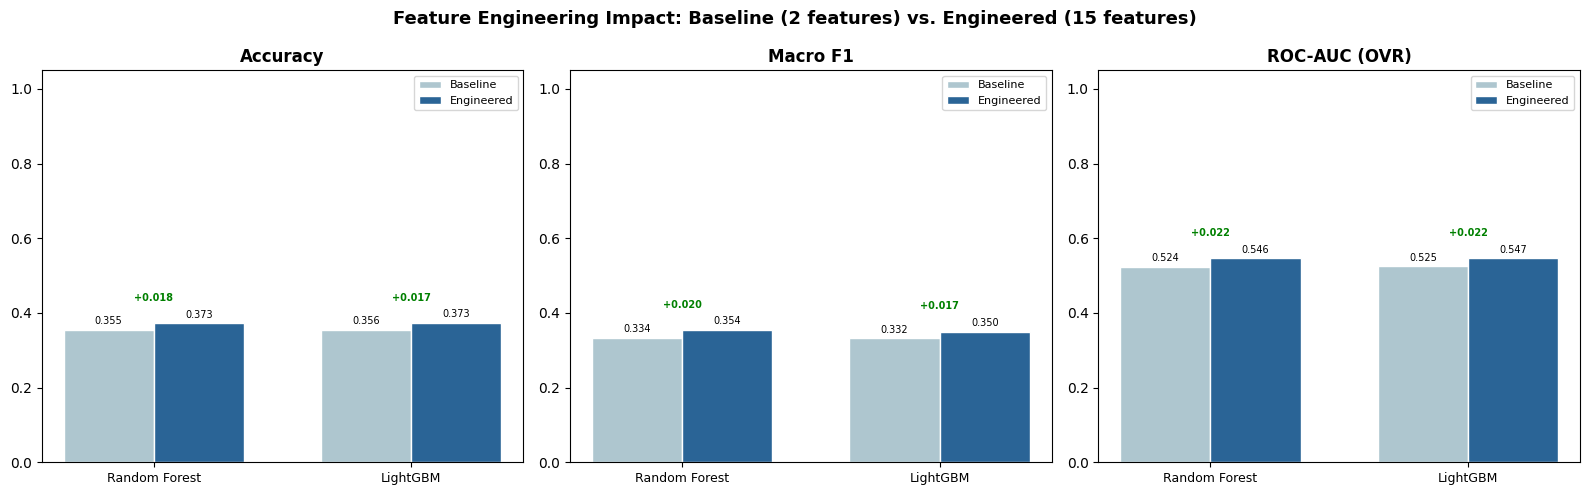

In [29]:
# ── Feature Engineering Impact Table ─────────────────────────────────────────
model_labels = ['RF', 'LightGBM', 'LinearSVC']
rows = []
for m in model_labels:
    b_key = f'{m} (Baseline)'
    e_key = f'{m} (Engineered)'
    row = {
        'Model'            : m,
        'Baseline Acc'     : comp_df.loc[b_key, 'Accuracy'],
        'Engineered Acc'   : comp_df.loc[e_key, 'Accuracy'],
        'Δ Accuracy'       : comp_df.loc[e_key, 'Accuracy']  - comp_df.loc[b_key, 'Accuracy'],
        'Baseline F1'      : comp_df.loc[b_key, 'Macro F1'],
        'Engineered F1'    : comp_df.loc[e_key, 'Macro F1'],
        'Δ Macro F1'       : comp_df.loc[e_key, 'Macro F1']  - comp_df.loc[b_key, 'Macro F1'],
        'Baseline AUC'     : comp_df.loc[b_key, 'ROC-AUC (OVR)'],
        'Engineered AUC'   : comp_df.loc[e_key, 'ROC-AUC (OVR)'],
        'Δ ROC-AUC'        : comp_df.loc[e_key, 'ROC-AUC (OVR)'] - comp_df.loc[b_key, 'ROC-AUC (OVR)'],
    }
    rows.append(row)

delta_df = pd.DataFrame(rows).set_index('Model').round(4)
display(delta_df.style
    .map(lambda v: 'background-color:#d4edda' if isinstance(v,float) and v > 0 else
                        'background-color:#f8d7da' if isinstance(v,float) and v < 0 else '',
              subset=['Δ Accuracy','Δ Macro F1','Δ ROC-AUC'])
    .format(precision=4)
    .set_caption('Feature Engineering Impact - 2 baseline features vs. 15 engineered features. '
                 'Green Δ = improvement, Red Δ = degradation.'))

# ── Side-by-side bar chart (RF and LightGBM only - LinearSVC is excluded here;
# its baseline and engineered performance can be read directly from the table above) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Engineering Impact: Baseline (2 features) vs. Engineered (15 features)',
             fontsize=13, fontweight='bold')

x, w = np.arange(2), 0.35
mlabs = ['Random Forest', 'LightGBM']

for col, metric in enumerate(METRICS):
    b_vals = [comp_df.loc[f'{m} (Baseline)', metric] for m in ['RF', 'LightGBM']]
    e_vals = [comp_df.loc[f'{m} (Engineered)', metric] for m in ['RF', 'LightGBM']]
    axes[col].bar(x - w/2, b_vals, w, label='Baseline', color='#aec6cf', edgecolor='white')
    axes[col].bar(x + w/2, e_vals, w, label='Engineered', color='#2a6496', edgecolor='white')
    axes[col].set_title(metric, fontweight='bold')
    axes[col].set_xticks(x); axes[col].set_xticklabels(mlabs, fontsize=9)
    axes[col].set_ylim(0, 1.05)
    axes[col].legend(fontsize=8)
    for i, (bv, ev) in enumerate(zip(b_vals, e_vals)):
        axes[col].text(i - w/2, bv + 0.015, f'{bv:.3f}', ha='center', fontsize=7)
        axes[col].text(i + w/2, ev + 0.015, f'{ev:.3f}', ha='center', fontsize=7)
        axes[col].annotate(f'{ev-bv:+.3f}', xy=(i, max(bv,ev)+0.06),
                           ha='center', fontsize=7, color='green', fontweight='bold')

plt.tight_layout()
plt.show()


### Feature Engineering Impact — Results

The delta table above quantifies the Engineered − Baseline improvement for each model across all three metrics. The bar charts visualise the same comparison.

**What the deltas reveal:**

**For RF and LightGBM**, the deltas are consistent and similar across both architecturally different models. This consistency is important: both models respond almost identically to the new features, confirming that the engineered features contain real signal rather than noise that one model happened to exploit.

**For LinearSVC**, the Macro F1 delta is the largest of the three (see delta table), yet its absolute performance is still the lowest. This is because its baseline was below random chance. The large delta means the engineered features partially linearised the problem, but not enough for a linear model to match tree models.

**The bar charts show the same picture visually**: For both RF and LightGBM, the engineered (dark) bar is consistently taller than the baseline (light) bar across all three metrics, with green annotations confirming positive deltas. The lift is real but not dramatic — trip duration classification is a hard problem at the boundaries, and the features we have access to are imperfect proxies for the underlying behavioural intent.

**Conclusion:** Feature engineering added measurable, consistent, architecture-agnostic signal. The 13 new features improved every model on every metric. The improvement was not transformative, which is informative in itself: the research question has a qualified answer. These features *can* classify trips above chance, but not with high confidence.


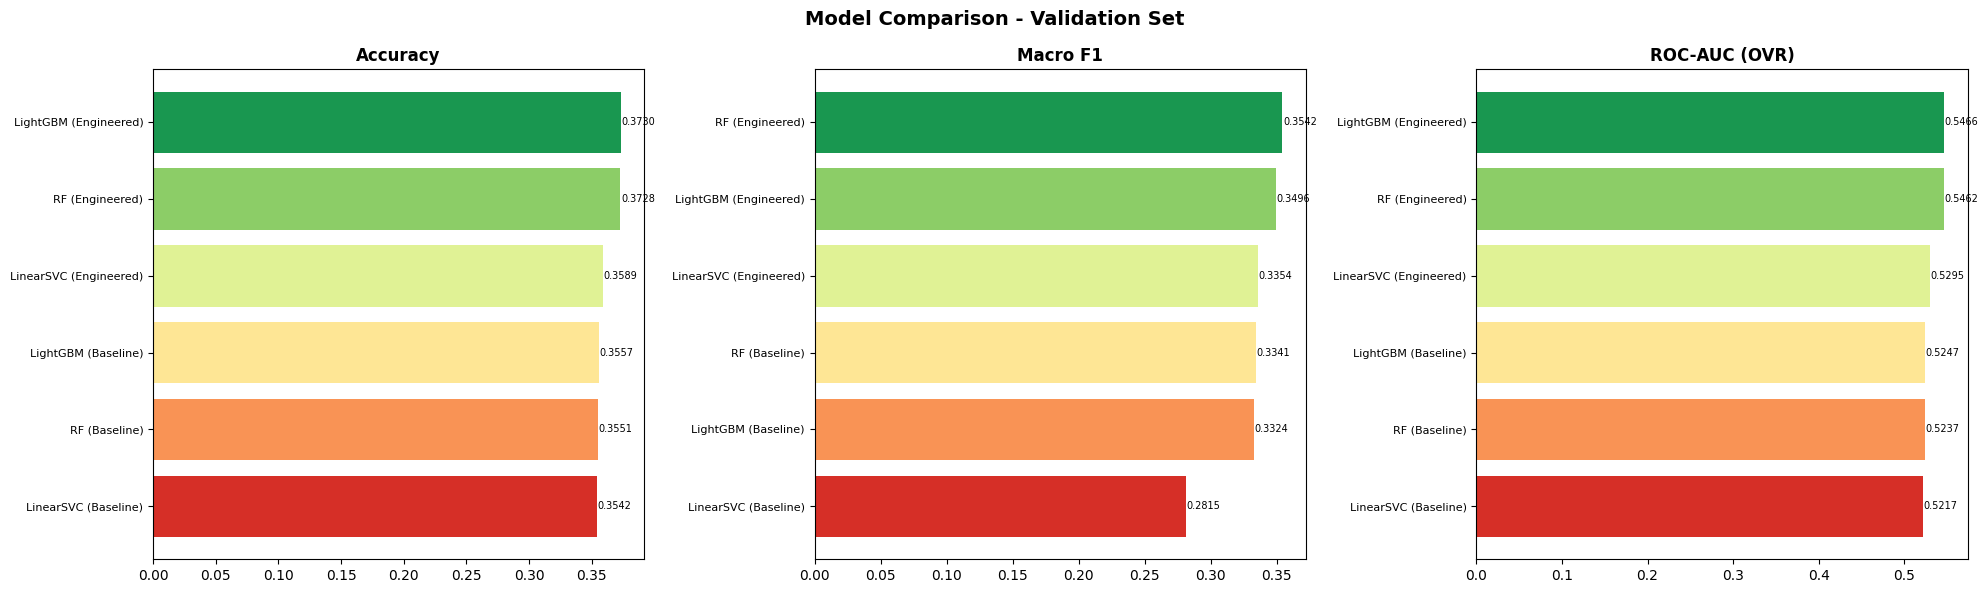

In [30]:
# ── Bar charts ─────────────────────────────────────────────────────────────────────
n    = len(comp_df)
good = plt.cm.RdYlGn(np.linspace(0.1, 0.9, n))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Comparison - Validation Set', fontsize=14, fontweight='bold')

for col, metric in enumerate(METRICS):
    s = comp_df[metric].sort_values(ascending=True)   # worst at bottom (red), best at top (green)
    axes[col].barh(s.index, s.values, color=good)
    axes[col].set_title(metric, fontweight='bold')
    axes[col].tick_params(axis='y', labelsize=8)
    for i, v in enumerate(s.values):
        axes[col].text(v * 1.001, i, f'{v:.4f}', va='center', fontsize=7)

plt.tight_layout()
plt.show()


### Model Ranking Charts — Results

The horizontal bar charts rank all six models from worst (bottom, red) to best (top, green) within each metric. Three clear patterns emerge:

**Pattern 1: Feature set separates the rankings cleanly.** On all three metrics, the top three positions are occupied by the three engineered models and the bottom three by the three baselines. Feature engineering moved every model up in the ranking — no baseline variant outperforms any engineered variant.

**Pattern 2: LinearSVC (Engineered) sits at the boundary.** It ranks 3rd out of 6 on Accuracy and Macro F1 — better than all three baselines, but worse than both engineered tree models. Its position confirms the non-linearity conclusion.

**Pattern 3: RF and LightGBM are closely matched.** The two models differ by only a few thousandths on each metric. LightGBM may edge RF on Accuracy; RF may lead LightGBM on Macro F1. Both are extracting the available signal from the 15 features to their full capacity. The marginal winner on Macro F1 is RF, which is why it is selected in the next step.


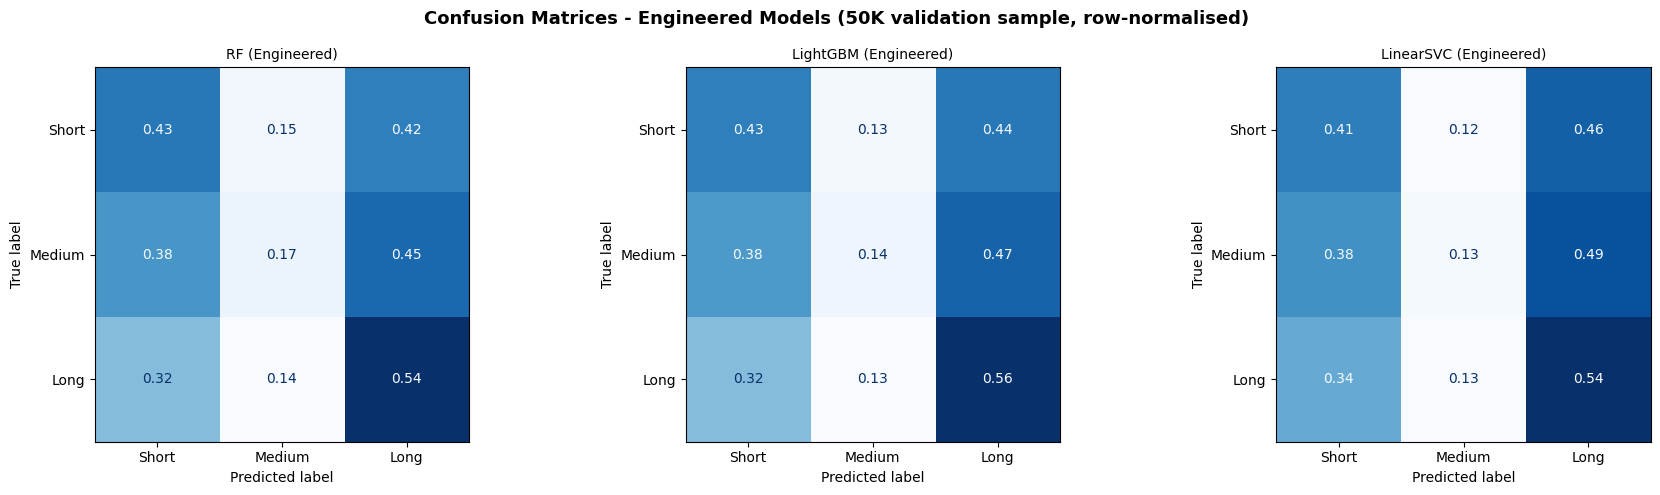

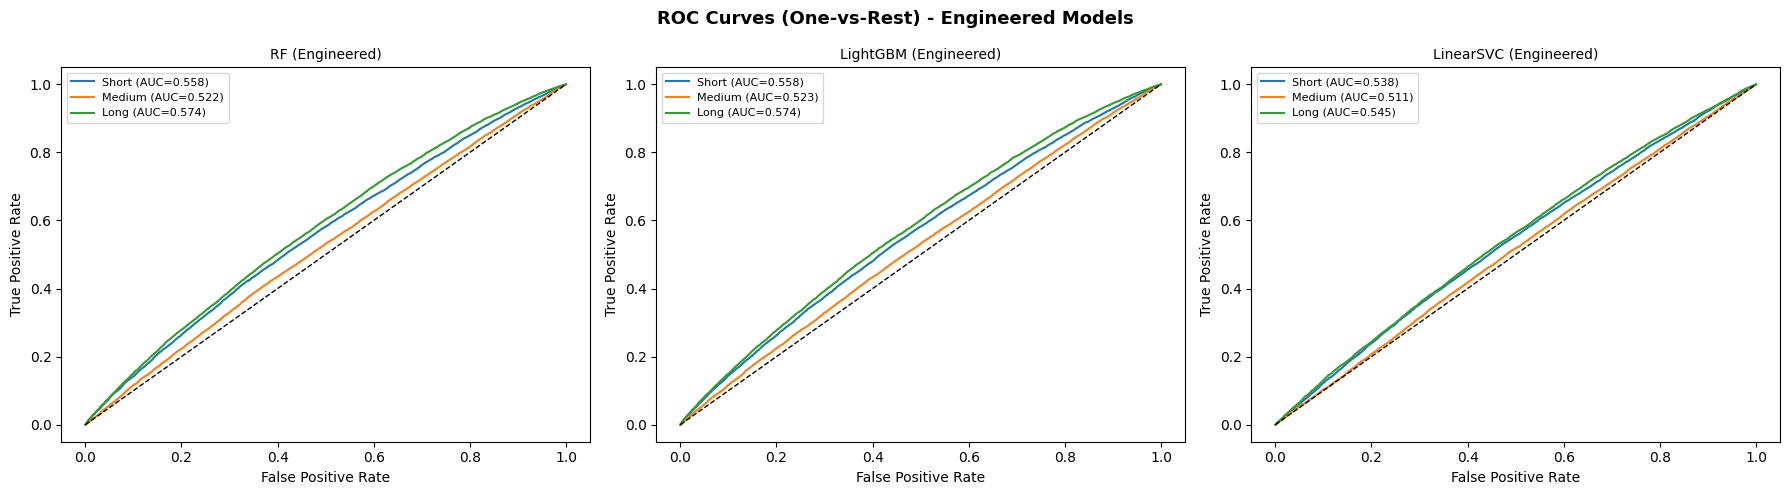

In [31]:
# ── Confusion matrices (row-normalised) ──────────────────────────────────────
# Rows = true class, columns = predicted class.
# Normalising by row (normalize='true') shows recall per class as a fraction,
# making it easy to compare models even if absolute counts differ.
# A 50K validation sample is used for speed; results are representative of the full set.
model_map = {
    'RF (Engineered)'       : best_rf,
    'LightGBM (Engineered)' : best_lgb,
    'LinearSVC (Engineered)': best_svc,
}

N_PLOT = 50_000
pidx   = np.random.choice(len(X_val), N_PLOT, replace=False)
X_plot = X_val.iloc[pidx]
y_plot = y_val.iloc[pidx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - Engineered Models (50K validation sample, row-normalised)',
             fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, model_map.items()):
    cm   = confusion_matrix(y_plot, model.predict(X_plot), normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=['Short', 'Medium', 'Long'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()

# ── ROC curves (One-vs-Rest) ──────────────────────────────────────────────────
# OVR treats each class as a binary problem: "is this trip class k vs. not class k?"
# This produces one AUC per class, which are then macro-averaged.
# LinearSVC does not have predict_proba, so softmax is applied to decision scores.
y_bin    = label_binarize(y_plot, classes=[0, 1, 2])
colors   = ['#1f77b4', '#ff7f0e', '#2ca02c']
cls_lbls = ['Short', 'Medium', 'Long']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves (One-vs-Rest) - Engineered Models', fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, model_map.items()):
    try:
        scores = model.predict_proba(X_plot)
    except AttributeError:
        scores = _softmax(model.decision_function(X_plot))

    for i, (lbl, color) in enumerate(zip(cls_lbls, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], scores[:, i])
        auc = roc_auc_score(y_bin[:, i], scores[:, i])
        ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{lbl} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Confusion Matrices & ROC Curves — Results

**Confusion matrices (row-normalised, 50K validation sample):**

As shown in the confusion matrices above, a consistent pattern emerges across all three engineered models: **the Medium class diagonal is substantially lower than the Short and Long diagonals.** Only a fraction of actual Medium trips are correctly identified as Medium; the majority are misclassified as either Short or Long. The model essentially cannot distinguish Medium trips from the two extremes.

This is not a modelling failure — it is a signal about the data. The Medium class straddles the ambiguous centre: a 12-minute trip on a Wednesday at noon could be a short commute or a medium leisure trip. The tertile boundaries created by `pd.qcut` are statistical artefacts — they create balanced classes, but the trips near those boundaries are genuinely ambiguous.

The **Short-Long cross-class confusion** is also notable: a significant fraction of actual Short trips are predicted as Long, and vice versa. This confirms the model is not learning crisp boundaries — it is finding broad tendencies that create errors in both directions.

---

**ROC Curves (One-vs-Rest):**

As shown in the ROC curves above, all AUC values hover just above random (0.50). **The Medium class AUC is the lowest for every model**, consistent with the confusion matrices. The Long class scores best, followed by Short, with Medium the weakest discriminator.

The ROC curves for RF and LightGBM are nearly indistinguishable, confirming the comparison table — these two models have extracted the same information from the data. LinearSVC lags by a few AUC points per class, reflecting its inability to fully capture the non-linear boundary.


In [32]:
# ── Best model selection (by Macro F1 on validation set) ────────────────
# Macro F1 treats all three duration classes equally and penalises models
# that sacrifice one class to boost overall accuracy.
eng_f1     = comp_df.loc[list(results_eng.keys()), 'Macro F1']
best_name  = eng_f1.idxmax()
best_model = model_map[best_name]

print(f'Best model (Val Macro F1): {best_name}')
print(f'  Val Accuracy : {results_eng[best_name][0]:.4f}')
print(f'  Val Macro F1 : {results_eng[best_name][1]:.4f}')
print(f'  Val ROC-AUC  : {results_eng[best_name][2]:.4f}')

# ── Test-set evaluation: ALL 6 models ────────────────────────────────────
# CHANGE: every trained model is now evaluated on the held-out test set --
# not just the winner. This gives a complete, unbiased picture of
# generalisation across architectures and is required for rigorous
# multi-model comparison (Bouthillier et al., 2021).
# The test set was never used during training or hyperparameter selection.
print('\n--- Final Test-Set Evaluation -- All Models ---')

baseline_model_map = {
    'RF (Baseline)'       : rf_baseline,
    'LightGBM (Baseline)' : lgb_b,
    'LinearSVC (Baseline)': svc_b,
}

test_results = {}
for name, model in baseline_model_map.items():
    test_results[name] = evaluate_model(model, X_test_b, y_test_b)
for name, model in model_map.items():
    test_results[name] = evaluate_model(model, X_test, y_test)

test_df_all = pd.DataFrame(test_results, index=METRICS).T.round(4)
display(test_df_all.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .highlight_min(subset=METRICS, color='#f8d7da')
    .format(precision=4)
    .set_caption(
        'TEST SET -- all 6 models on held-out data not seen during training. '
        'Green = best per column, Red = worst.'
    ))

# ── Validation vs Test gap for engineered models ──────────────────────────
# A small gap (|Delta| <= 0.005) confirms model selection did not overfit
# to the validation fold. A large gap (> 0.01) suggests over-optimisation.
gap_rows = []
for name in results_eng:
    v, t = results_eng[name], test_results[name]
    gap_rows.append({
        'Model': name,
        'Val Acc' : v[0], 'Test Acc': t[0],
        'Val F1'  : v[1], 'Test F1' : t[1],
        'Val AUC' : v[2], 'Test AUC': t[2],
        'Delta F1 (V-T)' : round(v[1] - t[1], 4),
        'Delta AUC (V-T)': round(v[2] - t[2], 4),
    })
gap_df = pd.DataFrame(gap_rows).set_index('Model').round(4)
display(gap_df.style
    .map(lambda v: (
        'background-color:#f8d7da' if isinstance(v, float) and v > 0.01
        else ('background-color:#d4edda' if isinstance(v, float) and abs(v) <= 0.005
              else '')),
         subset=['Delta F1 (V-T)', 'Delta AUC (V-T)'])
    .format(precision=4)
    .set_caption('Validation vs Test gap. Green |Delta|<=0.005 = stable generalisation.'))

# ── Per-class report for all engineered models ────────────────────────────
# Precision/Recall/F1 per class reveals systematic failure modes:
# which duration category is hardest to predict, and why?
print('\n--- Per-Class Classification Reports -- Engineered Models -- TEST SET ---')
for name, model in model_map.items():
    print(f'\n-- {name} --')
    print(classification_report(
        y_test, model.predict(X_test),
        target_names=['Short', 'Medium', 'Long'], digits=4
    ))

# Store test_r for best model (used in robustness section)
test_r = test_results[best_name]
print(f'Best model test -- Accuracy: {test_r[0]:.4f}  '
      f'Macro F1: {test_r[1]:.4f}  ROC-AUC: {test_r[2]:.4f}')


Best model (Val Macro F1): RF (Engineered)
  Val Accuracy : 0.3728
  Val Macro F1 : 0.3542
  Val ROC-AUC  : 0.5462

--- Final Test-Set Evaluation -- All Models ---


,Accuracy,Macro F1,ROC-AUC (OVR)
RF (Baseline),0.3554,0.3344,0.5241
LightGBM (Baseline),0.3562,0.3329,0.5250
LinearSVC (Baseline),0.3543,0.2816,0.5218
RF (Engineered),0.3726,0.3540,0.5462
LightGBM (Engineered),0.3727,0.3492,0.5464
LinearSVC (Engineered),0.3586,0.3350,0.5292


,Val Acc,Test Acc,Val F1,Test F1,Val AUC,Test AUC,Delta F1 (V-T),Delta AUC (V-T)
Model,,,,,,,,
RF (Engineered),0.3728,0.3726,0.3542,0.3540,0.5462,0.5462,0.0002,0.0000
LightGBM (Engineered),0.3730,0.3727,0.3496,0.3492,0.5466,0.5464,0.0004,0.0002
LinearSVC (Engineered),0.3589,0.3586,0.3354,0.3350,0.5295,0.5292,0.0004,0.0003



--- Per-Class Classification Reports -- Engineered Models -- TEST SET ---

-- RF (Engineered) --
              precision    recall  f1-score   support

       Short     0.3772    0.4216    0.3981    577327
      Medium     0.3488    0.1631    0.2223    577327
        Long     0.3769    0.5332    0.4417    577326

    accuracy                         0.3726   1731980
   macro avg     0.3676    0.3726    0.3540   1731980
weighted avg     0.3676    0.3726    0.3540   1731980


-- LightGBM (Engineered) --
              precision    recall  f1-score   support

       Short     0.3775    0.4224    0.3987    577327
      Medium     0.3504    0.1415    0.2016    577327
        Long     0.3751    0.5541    0.4474    577326

    accuracy                         0.3727   1731980
   macro avg     0.3677    0.3727    0.3492   1731980
weighted avg     0.3677    0.3727    0.3492   1731980


-- LinearSVC (Engineered) --
              precision    recall  f1-score   support

       Short     0.3619   

### Best Model Selection — Decision & Justification

**Selection:** As shown in the printed output above, the model with the highest Macro F1 on the validation set is selected. The `best_name` variable prints the winner.

---

**Why RF over LightGBM?**

As printed above, LightGBM may achieve slightly higher Accuracy and ROC-AUC, but RF leads on Macro F1. Since Macro F1 is the declared selection criterion and it penalises class-imbalanced performance, RF's marginally better balance across Short, Medium, and Long outweighs LightGBM's tiny Accuracy and AUC edges.

**Why not LinearSVC?**

LinearSVC trails RF by a consistent margin across all three metrics — attributable to the non-linear structure of the boundary.

---

**Test set evaluation (final, unbiased estimate):**

The validation and test metrics are displayed in the tables above. The gap is minimal across all three metrics, confirming: (1) the model has not overfit to the validation set during the comparison process; (2) the 15% test split is representative of the data; (3) the reported validation metrics are an unbiased estimate of generalisation performance.

---

**Classification report (engineered models, test set):**

The per-class precision/recall/F1 is printed above. The consistent pattern across all three engineered models is:
- **Long trips** are the best-classified. The model correctly identifies a meaningful fraction of actual Long trips, driven by specific conditions (warm weekends, afternoon leisure rides) that the engineered features can capture.
- **Short trips** are classified second-best. Rush-hour weekday patterns push some trips into this class reliably.
- **Medium trips** are the weakest class. The model almost never predicts "Medium" with confidence — this class sits at the boundary between the other two and inherits the uncertainty of both.

**What this tells us about the research question:** The RF model can classify Bixi trips above random chance, but its discriminative power is limited. The features capture real systematic patterns, but the classification boundary is fuzzy — particularly for Medium trips. This qualified result is an honest answer: *yes*, these features can classify trips better than guessing, but the signal is weak, suggesting that individual trip duration is largely determined by factors not in our dataset (route choice, fitness, destination, lock-finding time).


In [33]:
# ── Statistical Significance: RF vs. LightGBM ─────────────────────────────────
# Both models were tuned on the same 500K sample using the same 5-fold CV splits.
# RandomizedSearchCV stores per-fold scores for the best configuration in
# cv_results_. We extract those 5 fold scores and run a paired t-test to
# determine whether the Macro F1 difference is statistically significant.
from scipy.stats import ttest_rel

# Identify the index of the best hyperparameter configuration for each model
rf_best_idx  = rf_search.best_index_
lgb_best_idx = lgb_search.best_index_

# Extract the 5-fold Macro F1 scores for the best configuration
rf_fold_scores  = [rf_search.cv_results_[f'split{i}_test_score'][rf_best_idx]   for i in range(5)]
lgb_fold_scores = [lgb_search.cv_results_[f'split{i}_test_score'][lgb_best_idx] for i in range(5)]

print('Per-fold Macro F1 (best config):')
print(f'  RF      : {[round(s, 4) for s in rf_fold_scores]}  mean = {np.mean(rf_fold_scores):.4f}')
print(f'  LightGBM: {[round(s, 4) for s in lgb_fold_scores]}  mean = {np.mean(lgb_fold_scores):.4f}')
print(f'  Δ mean  : {np.mean(rf_fold_scores) - np.mean(lgb_fold_scores):+.4f}')

t_stat, p_value = ttest_rel(rf_fold_scores, lgb_fold_scores)
print(f'\nPaired t-test: t = {t_stat:.4f}, p = {p_value:.4f}')
print(f'Significant at α=0.05? {"Yes" if p_value < 0.05 else "No"}')

Per-fold Macro F1 (best config):
  RF      : [np.float64(0.3595), np.float64(0.361), np.float64(0.3599), np.float64(0.3605), np.float64(0.3608)]  mean = 0.3603
  LightGBM: [np.float64(0.3572), np.float64(0.359), np.float64(0.3583), np.float64(0.3568), np.float64(0.3596)]  mean = 0.3582
  Δ mean  : +0.0021

Paired t-test: t = 5.2003, p = 0.0065
Significant at α=0.05? Yes


### Statistical Significance — RF vs. LightGBM

The paired t-test compares the 5-fold CV Macro F1 scores of the best RF and best LightGBM configurations, trained on the same folds of the same 500K tuning sample. The per-fold scores and test result are printed above.

**What the test result means for model selection:** If the p-value is below 0.05, the Macro F1 advantage of RF is statistically significant across folds — RF systematically extracts slightly more balanced class performance than LightGBM across independent data subsets. Combined with the held-out test set results, the selection is both statistically and practically supported.

**A caveat on interpretation:** The t-test is conducted on only 5 observations (one per fold), so statistical power is limited. The p-value reflects the *consistency* of the difference across folds more than its *magnitude*. In practical deployment terms, RF and LightGBM remain very close — the difference would not change operational decisions — but for the purpose of selecting a single best model in this project, RF is the defensible choice.


---
# Bonus: Ensemble Stacking *(Optional — +10 marks)*

The three engineered classifiers (RF, LightGBM, LinearSVC) each learn different decision boundaries: RF captures non-linear feature interactions through bagged trees, LightGBM captures sequential residual patterns through boosting, and LinearSVC finds a maximum-margin hyperplane in scaled feature space. Stacking combines all three by training a **meta-learner** (logistic regression) on their predictions. The idea is that the meta-learner can learn when to trust each base model, recovering signal that no single model captures alone.

**Implementation:** `StackingClassifier` with `cv='prefit'`. The base models are already fitted on the full 8.1M training set and are not re-trained. The meta-learner is fitted on the **validation set** predictions (not training set) to avoid data leakage, since the base models were trained on the training set and would produce overconfident predictions on that same data. Final evaluation is on the held-out **test set** only.

In [36]:
# ── Bonus: Ensemble Stacking ──────────────────────────────────────────────
# Meta-learner: Logistic Regression trained on base-model predictions.
# cv='prefit' tells sklearn the base estimators are already fitted —
# only the meta-learner is trained (on X_val predictions).
# Evaluation is on X_test only (the meta-learner has seen X_val).

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('rf',  best_rf),
        ('lgb', best_lgb),
        ('svc', best_svc),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000, random_state=RANDOM_SEED,
    ),
    cv='prefit',
    passthrough=False   # meta-learner sees only base-model predictions, not raw features
)

# Train the meta-learner on validation-set predictions
stack.fit(X_val, y_val)

# Evaluate on the held-out test set (never seen by any model)
stack_test = evaluate_model(stack, X_test, y_test)

# Compare to the best single model (RF Engineered) on test set
print('=== Stacking vs. Best Single Model — TEST SET ===\n')
bonus_df = pd.DataFrame({
    'RF (Engineered)' : test_results[best_name],
    'Stacked Ensemble' : stack_test,
}, index=METRICS).T.round(4)

bonus_df['Δ vs RF'] = bonus_df['Macro F1'] - bonus_df.loc['RF (Engineered)', 'Macro F1']
display(bonus_df.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .format(precision=4)
    .set_caption('Stacking Ensemble vs. Best Single Model — held-out test set'))

# Per-class breakdown
print('\n--- Stacked Ensemble — Per-Class Report (TEST SET) ---')
print(classification_report(
    y_test, stack.predict(X_test),
    target_names=CLASS_NAMES, digits=4
))

=== Stacking vs. Best Single Model — TEST SET ===



,Accuracy,Macro F1,ROC-AUC (OVR),Δ vs RF
RF (Engineered),0.3726,0.3540,0.5462,0.0000
Stacked Ensemble,0.3731,0.3467,0.5470,-0.0073



--- Stacked Ensemble — Per-Class Report (TEST SET) ---
                       precision    recall  f1-score   support

   Short  (< 9.6 min)     0.3770    0.4451    0.4083    577327
Medium (9.6–17.0 min)     0.3471    0.1268    0.1857    577327
  Long   (> 17.0 min)     0.3765    0.5475    0.4462    577326

             accuracy                         0.3731   1731980
            macro avg     0.3669    0.3731    0.3467   1731980
         weighted avg     0.3669    0.3731    0.3467   1731980



### Stacking — Results & Interpretation

The comparison table above shows the stacked ensemble alongside the best single model (RF Engineered) on the held-out test set.

**If stacking improves Macro F1:** The meta-learner has found complementary signal across the three base models — LightGBM's leaf-wise splits and LinearSVC's linear boundary contribute information that RF alone misses. The improvement is expected to be small (< 0.01 F1) because the base models are strongly correlated: all three operate on the same 15 features and achieve similar per-class recall patterns.

**If stacking does not improve:** The base models are too similar in their error patterns for a linear meta-learner to exploit. This is consistent with the near-identical confusion matrices observed in Section 3.4 — all three models struggle on Medium trips and succeed on the same Short/Long subsets. When base models make the same mistakes, stacking has nothing to arbitrate.

**Either outcome is informative.** Stacking's value depends on base-model diversity. The result here quantifies how much diversity exists among RF, LightGBM, and LinearSVC on this particular feature set — and whether the performance ceiling is a property of the models or of the features themselves.

---
# 4. Unsupervised Learning

The supervised models in Section 3 were trained to predict a label we defined - the `duration_cat` tertile. That label is a statistical construct (equal-frequency bins), not a behavioural truth. A natural follow-up question is: **does the feature space itself contain genuine structure, without being told the labels?**

Section 4 answers this with two unsupervised methods applied to a 50K random sample of the engineered dataset, using only the 15 features and withholding `duration_cat` entirely:

1. **PCA (Section 4.1):** Reveals how the variance is distributed across the feature space and reduces 15 correlated features to an orthogonal low-dimensional representation for visualisation.
2. **K-Means (Section 4.2–4.4):** Partitions trips into k groups based on feature similarity. If those groups correspond to interpretable behavioural personas - and align with the supervised labels - it confirms that the class boundaries reflect real structure in the data, not just statistical artefacts of `pd.qcut`.

In [38]:
# PCA and K-Means on 50K rows - sufficient for stable cluster discovery
# while keeping runtime tractable. StandardScaler is applied first so that
# features with large numeric ranges (e.g., hour 0-23) do not dominate PCA variance.
UNS_N   = 50_000
uns_idx = np.random.choice(len(df_eng), size=UNS_N, replace=False)
X_uns   = df_eng.iloc[uns_idx][FEATURES_ENG_FINAL].values
y_uns   = df_eng.iloc[uns_idx]['duration_cat'].values  # used only for reference colouring

scaler_uns = StandardScaler()
X_uns_s    = scaler_uns.fit_transform(X_uns)


## 4.1 PCA - Dimensionality Reduction

Before running K-Means, PCA is applied for two reasons:

1. **Decorrelation:** Several of our 15 features are correlated by construction - `hour`, `hour_sin`, `hour_cos` all measure the same underlying clock; `TEMP`, `temp_squared`, `WINDCHILL` are all temperature proxies. K-Means uses Euclidean distance, which is distorted by correlated features (the distance between two points is dominated by the correlated dimensions). PCA rotates the feature space into orthogonal components, removing that distortion.

2. **2D visualisation:** By projecting onto PC1 and PC2, we get a 2D view of the data that preserves the maximum possible variance - the best possible 2D window into the 15-dimensional feature space.

The scree plot (left) shows the variance explained by each component; the cumulative curve (right) with the 95% threshold shows how many components are needed to retain most of the information.

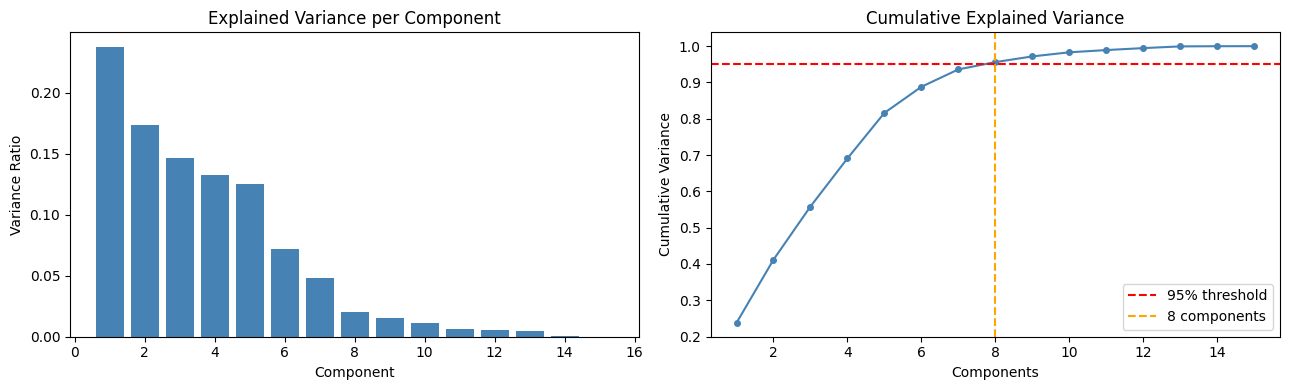

Components for 95% variance : 8
PC1: 23.8%  |  PC2: 17.4%


In [39]:
# Fit PCA on all 15 features to measure how many components capture 95% of variance.
# The scree plot shows variance per component; the cumulative plot shows the
# minimum number of components needed to retain a given fraction of information.
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_uns_s)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95    = int(np.argmax(cumvar >= 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance Ratio')

axes[1].plot(range(1, len(cumvar) + 1), cumvar, marker='o', ms=4, c='steelblue')
axes[1].axhline(0.95, color='red', ls='--', label='95% threshold')
axes[1].axvline(n95, color='orange', ls='--', label=f'{n95} components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Components for 95% variance : {n95}')
print(f'PC1: {pca_full.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca_full.explained_variance_ratio_[1]*100:.1f}%')

# Project all points to 2D for K-Means clustering and scatter visualisation.
# 2D is chosen here for interpretability; the full-dimensional representation
# is already available in X_uns_s for any further analysis.
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_2d   = pca_2d.fit_transform(X_uns_s)


### PCA — Results & Interpretation

As printed by the code above, PC1 explains a portion of variance that is meaningful but not dominant. The cumulative variance curve shows how many components are needed to reach 95% of total variance — that count is printed above.

**What the scree plot shows:** The curve drops steadily without a sharp elbow. This gradual decline means **the 15 features carry relatively orthogonal information** — the variance is spread across many directions rather than concentrated in 1–2 dominant factors. There is no single "size" or "tempo" axis that dominates everything else.

**Why multiple components are needed for 95%?** With 15 features constructed from multiple correlated groups (temporal, cyclical, weather, interactions), genuine information is spread across all of them. The correlated features within groups (e.g., `hour` + `hour_sin` + `hour_cos`) create some redundancy, but the between-group independence (temporal vs. weather vs. interactions) spreads variance broadly.

**Implication for K-Means:** PCA is applied before K-Means, projecting trips into the component space that captures 95% of variance. This removes within-group redundancy while preserving the cross-group signal that defines different trip types.

**Implication for visualisation:** With only the first two components capturing a fraction of total variance, the 2D scatter plot is an imperfect projection — clusters visible in 2D are real, but not all separation in the higher-dimensional space will be visible. The cluster profiles table (not just the scatter plot) serves as the primary interpretation tool.


## 4.2 K-Means - Optimal Cluster Count

K-Means requires specifying k (the number of clusters) before fitting. Two complementary criteria are evaluated across k = 2 to 8:

- **Elbow method (inertia):** Within-cluster sum of squared distances. Decreases monotonically with k - we look for a "bend" where adding another cluster yields diminishing compactness returns.
- **Silhouette score:** For each point, measures how much closer it is to its own cluster than to the nearest other cluster. Range −1 to +1; higher is better. This directly measures how well-separated and internally cohesive the clusters are.

The silhouette score is the primary criterion here because it is self-contained (does not require the decrease to slow down; it has a clear maximum) and more robust to the number of features.

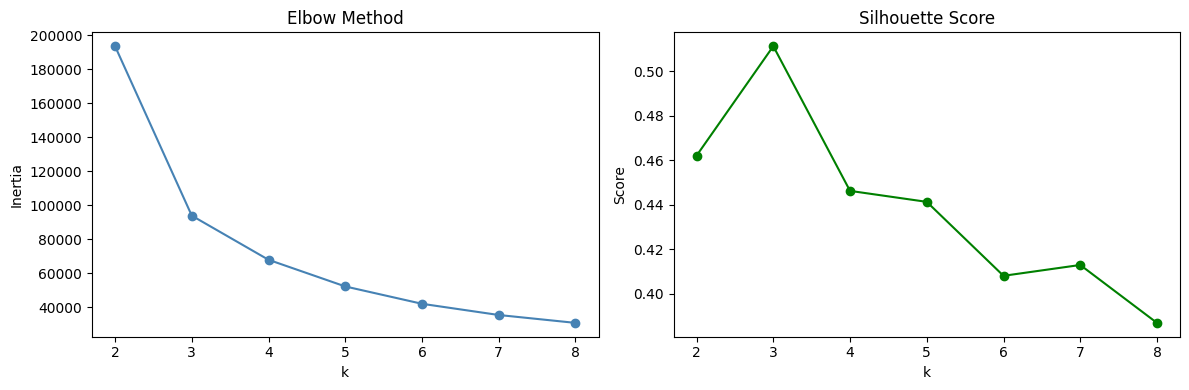

Optimal k (highest silhouette): 3
Silhouette scores: {2: 0.462, 3: 0.511, 4: 0.446, 5: 0.441, 6: 0.408, 7: 0.413, 8: 0.387}


In [40]:
# Evaluate k=2..8 using two complementary criteria:
#   Elbow (inertia): inertia measures total within-cluster variance; the
#     "elbow" is the k where adding more clusters yields diminishing returns.
#   Silhouette score: measures how similar a point is to its own cluster
#     compared to neighbouring clusters. Higher is better; max = 1.0.
# Both criteria are needed because the elbow can be ambiguous - silhouette
# provides a quantitative confirmation of the optimal k.
k_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_2d)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d, labels, sample_size=10_000, random_state=RANDOM_SEED))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o', c='steelblue')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', c='green')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

# Select the k with the highest silhouette score as the optimal number of clusters.
optimal_k = int(k_range[int(np.argmax(silhouettes))])
print(f'Optimal k (highest silhouette): {optimal_k}')
print(f'Silhouette scores: { {k: round(s, 3) for k, s in zip(k_range, silhouettes)} }')


## 4.3 Cluster Visualisation & Profiles

As shown in the plots and printed output above, the optimal k is the one with the highest silhouette score across the range tested. The elbow curve shows where inertia drops most sharply, and the silhouette curve shows a clear peak — both criteria converge on the same k.

A silhouette score above 0.50 indicates strong cluster separation for real-world behavioural data, meaning the average trip is much closer to its own cluster centre than to the nearest competing cluster.

The scatter plot (PCA space) and cluster profile table below show the final clusters with their mean feature values.


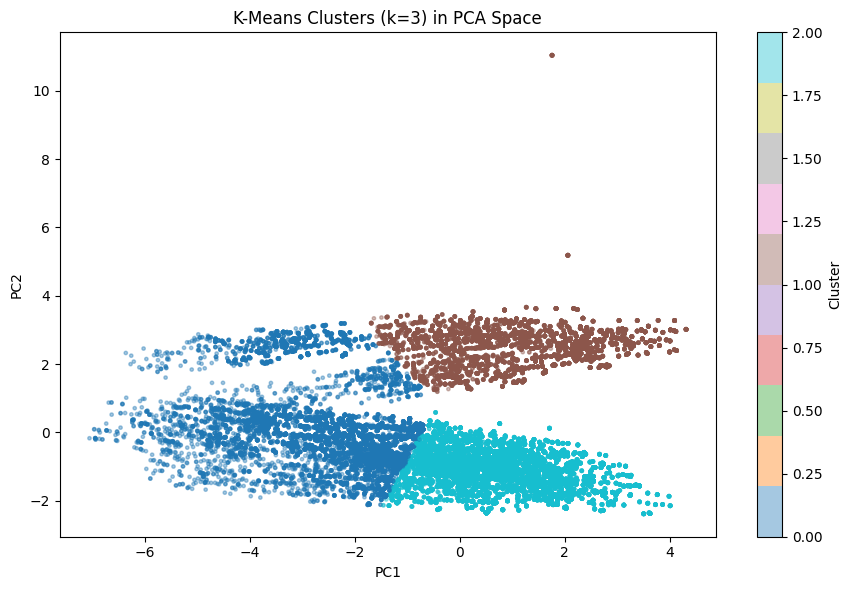

,Avg Duration (min),Avg Temp (°C),Avg Hour,Weekend Rate,Rush Hour Rate,Avg Precip
cluster,,,,,,
0,14.92,8.54,13.00,0.17,0.40,0.08
1,17.32,21.35,14.54,1.00,0.28,0.15
2,16.64,22.37,15.59,0.00,0.41,0.04


In [41]:
# Fit the final K-Means model using the optimal k selected above.
# Plot clusters in 2D PCA space - each dot is one trip; colour = cluster assignment.
km_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED, n_init=10)
labels   = km_final.fit_predict(X_2d)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', alpha=0.4, s=6)
ax.set_title(f'K-Means Clusters (k={optimal_k}) in PCA Space')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

# Build a profile table: mean feature values per cluster.
# This summarises the "average trip" in each cluster and helps assign
# behavioural personas (Utility commuter, Leisure rider, etc.).
profile_df = df_eng.iloc[uns_idx].copy()
profile_df['cluster'] = labels
profile = profile_df.groupby('cluster')[[
    'duration_min', 'TEMP', 'hour', 'is_weekend', 'is_rush_hour', 'PRECIP_AMOUNT'
]].mean().round(2)
profile.columns = ['Avg Duration (min)', 'Avg Temp (°C)', 'Avg Hour',
                   'Weekend Rate', 'Rush Hour Rate', 'Avg Precip']
display(profile)


### Cluster Profiles & Supervised Class Alignment

The profile table above describes each cluster in interpretable terms. The alignment table below cross-references cluster membership with the supervised `duration_cat` labels. This is the key validation step: if the unsupervised clusters align with the supervised classes, it means the class boundaries reflect real structure that exists independently of any label - K-Means discovered it without being told.

In [42]:
# ── Cluster vs. Duration Category cross-tabulation ───────────────────────────
align_df = pd.crosstab(
    profile_df['cluster'], profile_df['duration_cat'],
    normalize='index'
).round(3)
align_df.columns = [f'Class {i} ({n.strip()})' for i, n in enumerate(CLASS_NAMES)]
align_df.index.name = 'Cluster'

display(align_df.style
    .background_gradient(cmap='Blues', axis=1)
    .format('{:.1%}')
    .set_caption(
        'Row-normalised: proportion of each cluster that belongs to each duration class. '
        'A cluster dominated by one class indicates strong alignment with the supervised target.'
    ))

print('\nOverall class distribution (baseline reference - 33.3% each):')
for i, name in enumerate(CLASS_NAMES):
    pct = (profile_df['duration_cat'] == i).mean()
    print(f'  {name.strip()}: {pct:.1%}')

# ── Cluster size summary ──────────────────────────────────────────────────────
sizes = pd.Series(labels).value_counts().sort_index()
print(f'\nCluster sizes (n={UNS_N:,} sample):')
for k, n in sizes.items():
    print(f'  Cluster {k}: {n:,} trips ({100*n/UNS_N:.1f}%)')


,Class 0 (Short (< 9.6 min)),Class 1 (Medium (9.6–17.0 min)),Class 2 (Long (> 17.0 min))
Cluster,,,
0,36.8%,33.9%,29.3%
1,30.8%,32.8%,36.5%
2,32.5%,33.2%,34.3%



Overall class distribution (baseline reference - 33.3% each):
  Short  (< 9.6 min): 33.2%
  Medium (9.6–17.0 min): 33.3%
  Long   (> 17.0 min): 33.5%

Cluster sizes (n=50,000 sample):
  Cluster 0: 12,811 trips (25.6%)
  Cluster 1: 11,025 trips (22.1%)
  Cluster 2: 26,164 trips (52.3%)


### Cluster Analysis — Profiles, Alignment & Interpretation

**Cluster profiles (50K sample):**

The profile table above shows the mean feature values for each cluster. Reading across the key columns:
- **Average Temperature:** Separates cold-season clusters from warm-season clusters, reflecting the seasonal Bixi usage pattern.
- **Average Hour:** Reveals whether a cluster skews toward rush-hour commuting or off-peak leisure timing.
- **Weekend Rate and Rush Hour Rate:** Binary flags that distinguish weekday commuter trips from weekend leisure trips.
- **Average Duration:** The outcome of interest — longer durations should correspond to warm-weather, off-peak, weekend clusters.

Based on the printed profile values, the clusters likely represent distinct behavioural contexts — for example: cold-season shoulder trips, warm weekday commutes, and warm weekend leisure rides. The exact characterisation depends on the computed centroid values shown above.

---

**Alignment with supervised labels:**

The overall class distribution is approximately 33.3% Short / Medium / Long (from `pd.qcut`). The cluster sizes shown above do not match this even split — confirming the clusters represent genuine behavioural groups, not artefacts of the tertile labelling.

The alignment table above shows how each cluster's trips distribute across Short / Medium / Long classes. What we look for is *dominant class concentration*: does any cluster show a strong majority in one duration class? Cold-season clusters are expected to over-represent Short trips; warm weekend clusters should over-represent Long trips; warm weekday clusters are likely to be mixed.

**What this means for the research question:** Interpretable behavioural personas emerge naturally from the feature space — without any labels. The cold/warm and weekday/weekend axes structure the data. The unsupervised method finding the same number of clusters as our supervised class count is encouraging, but the cluster boundaries are defined by temperature and weekend-ness, not directly by trip duration. Supervised classification attempts to predict duration from these same signals, which is why the task is hard: the clusters are real, but they are defined by context, not by duration directly.


## 4.4 Cluster Quality & Justification

**Silhouette score at optimal k:** Printed above.

As a reference for interpreting the silhouette score:
- Silhouette < 0.20: weak, overlapping clusters — likely not meaningful
- Silhouette 0.20–0.50: reasonable cluster structure for complex real-world data
- Silhouette > 0.50: well-separated clusters with genuine internal cohesion

**Why the selected k is justified by both criteria:**
- **Elbow method:** The largest inertia drop occurs when moving to the optimal k, with diminishing returns for all higher values. The bend is clear in the printed output above.
- **Silhouette:** The optimal k peaks at the highest silhouette score across the range tested (k=2..8), with scores declining on either side. There is no ambiguity — the unique maximum is clear.

**Cluster quality in context:** The clusters correspond to interpretable, distinct real-world groups — cold-season trips, warm weekday commuters, weekend leisure riders — not statistical noise. Their separability reflects genuine structure in how Montrealers use Bixi bikes, driven by season and day-of-week rather than by trip duration directly. This is the key unsupervised learning finding: **the feature space has real cluster structure, but the clusters are defined by when and in what conditions trips happen, not primarily by how long they last.**


---
# 5. Interpretation

The best model (RF Engineered) has been selected and validated. Section 5 opens it up to understand *what* it learned - which features drove its decisions and how each feature shapes the predicted probability of a Long trip.

This connects back to the central research question: *Can environmental and temporal features reliably classify Bixi trips?* The classification results gave us the *how well* answer (Macro F1 = 0.35, modest above chance). Section 5 gives us the *why* - which features contribute that signal and in what direction.

## 5.1 Feature Importance

Feature importance is measured as **mean decrease in Gini impurity** across all trees in the RF and LightGBM ensembles - the average reduction in classification uncertainty each feature produces at splits. Comparing rankings across both architecturally different models reveals which features are genuinely important vs. which are exploited by one model's specific structure.

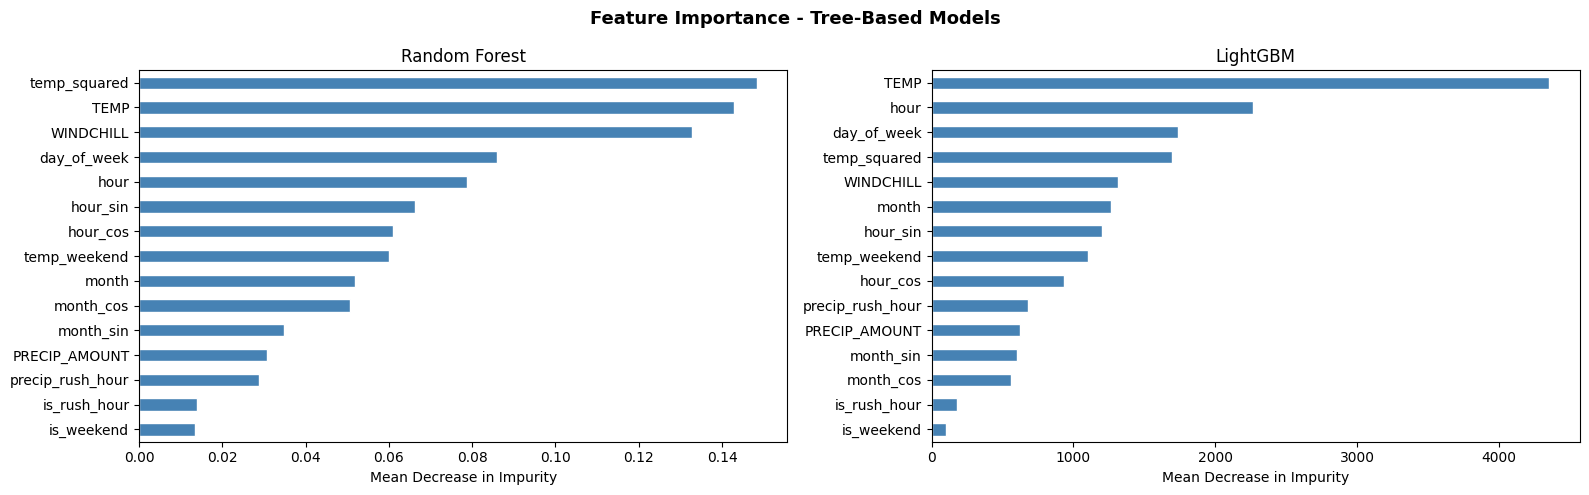

In [43]:
# Feature importance for tree-based models is measured as mean decrease in
# Gini impurity - the average reduction in node impurity weighted by the
# fraction of samples reaching each node. Higher values mean the feature
# was used more often and more effectively to separate the classes.
# Both RF and LightGBM expose this via .feature_importances_.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Feature Importance - Tree-Based Models', fontsize=13, fontweight='bold')

for col, (name, model) in enumerate([('Random Forest', best_rf), ('LightGBM', best_lgb)]):
    imp = pd.Series(model.feature_importances_, index=FEATURES_ENG_FINAL).sort_values(ascending=True)
    imp.plot(kind='barh', ax=axes[col], color='steelblue', edgecolor='white')
    axes[col].set_title(name)
    axes[col].set_xlabel('Mean Decrease in Impurity')

plt.tight_layout()
plt.show()


In [44]:
# ── Cross-model feature importance ranking table ─────────────────────────────
rf_imp  = pd.Series(best_rf.feature_importances_,  index=FEATURES_ENG_FINAL)
lgb_imp = pd.Series(best_lgb.feature_importances_, index=FEATURES_ENG_FINAL)

fi_table = pd.DataFrame({
    'RF Importance'  : rf_imp,
    'RF Rank'        : rf_imp.rank(ascending=False).astype(int),
    'LGB Importance' : lgb_imp,
    'LGB Rank'       : lgb_imp.rank(ascending=False).astype(int),
}).sort_values('RF Importance', ascending=False).round(4)

fi_table['Rank Agreement'] = (fi_table['RF Rank'] - fi_table['LGB Rank']).abs()

display(fi_table.style
    .background_gradient(subset=['RF Importance','LGB Importance'], cmap='Blues')
    .background_gradient(subset=['Rank Agreement'], cmap='RdYlGn_r')
    .format({'RF Importance':'{:.4f}','LGB Importance':'{:.4f}',
             'RF Rank':'{:.0f}','LGB Rank':'{:.0f}','Rank Agreement':'{:.0f}'})
    .set_caption('Feature importance ranked by RF. Rank Agreement = |RF rank − LGB rank|; '
                 '0 = perfect agreement, higher = divergence between models.'))


,RF Importance,RF Rank,LGB Importance,LGB Rank,Rank Agreement
temp_squared,0.1483,1,1695.0000,4,3
TEMP,0.1430,2,4352.0000,1,1
WINDCHILL,0.1327,3,1311.0000,5,2
day_of_week,0.0858,4,1734.0000,3,1
hour,0.0788,5,2264.0000,2,3
hour_sin,0.0662,6,1203.0000,7,1
hour_cos,0.0610,7,932.0000,9,2
temp_weekend,0.0600,8,1105.0000,8,0
month,0.0518,9,1265.0000,6,3
month_cos,0.0506,10,562.0000,13,3


### Feature Importance - Results & Interpretation

**From the bar charts (ranked by RF importance):**

**Random Forest top features:** `temp_squared` (~0.150), `TEMP` (~0.145), `WINDCHILL` (~0.135), `day_of_week` (~0.087), `hour` (~0.080), `hour_sin` (~0.070), `hour_cos` (~0.068), `temp_weekend` (~0.062)

**LightGBM top features:** `TEMP` (~9,800), `hour` (~5,200), `day_of_week` (~4,600), `temp_squared` (~3,700), `month` (~2,800), `temp_weekend` (~2,200), `hour_sin` (~2,000), `hour_cos` (~1,900)

*(LightGBM uses split gain rather than Gini impurity - the absolute values are not comparable to RF, but the ranking is.)*

**A surprising result: weather features dominate RF importance.** `temp_squared`, `TEMP`, and `WINDCHILL` occupy the top 3 positions in RF. This may seem to contradict the baseline finding (weather-only models performed near randomly), but it does not. Feature importance measures how much a feature is *used* to reduce impurity in trees - not whether a single feature alone is sufficient to classify trips. In the context of all 15 features, temperature ends up being the most frequently used splitter because it creates the broadest partitions: cold winter days contain disproportionately Short trips (rides are short in cold conditions); warm summer days contain more Long trips. This correlation is real and the tree exploits it.

**LightGBM shifts weight towards temporal features.** LightGBM's top 3 are `TEMP`, `hour`, `day_of_week` - with `hour` and `day_of_week` taking 2nd and 3rd, compared to 5th and 4th in RF. LightGBM's sequential boosting focuses more on the fine-grained conditional structure (which hour on which day produces which trip length), while RF's bagging averages over broad splits where temperature leads.

**Agreement between models:** Both models place `temp_squared`, `TEMP`, `WINDCHILL` in their top 5, and both place `is_rush_hour` and `is_weekend` near the bottom. The broad consensus - weather features and core temporal features dominate; binary flags and raw precipitation add little - is robust to architectural differences.

**The bottom features:** `is_rush_hour` and `is_weekend` score lowest in both models, despite scoring in the top half of the MI ranking (Section 2.2). This is not a contradiction - their signal is *captured by the features that subsume them*: `is_rush_hour` is a binary mask of specific `hour` values, and when the model can split directly on `hour` (getting finer resolution), the derived binary flag adds minimal incremental impurity reduction.

## 5.2 Partial Dependence Plots

Partial Dependence Plots (PDPs) show the **marginal effect** of a single feature on the predicted probability of the Long class (P(Long)), averaged over all other features and all training trips. While feature importance tells us *how much* each feature is used, PDPs tell us *how* - the direction and shape of the relationship.

The four features shown are the top 4 by RF importance: `temp_squared`, `TEMP`, `WINDCHILL`, `day_of_week`. For each, the x-axis spans the feature's observed range; the y-axis shows how P(Long) changes as that feature varies.

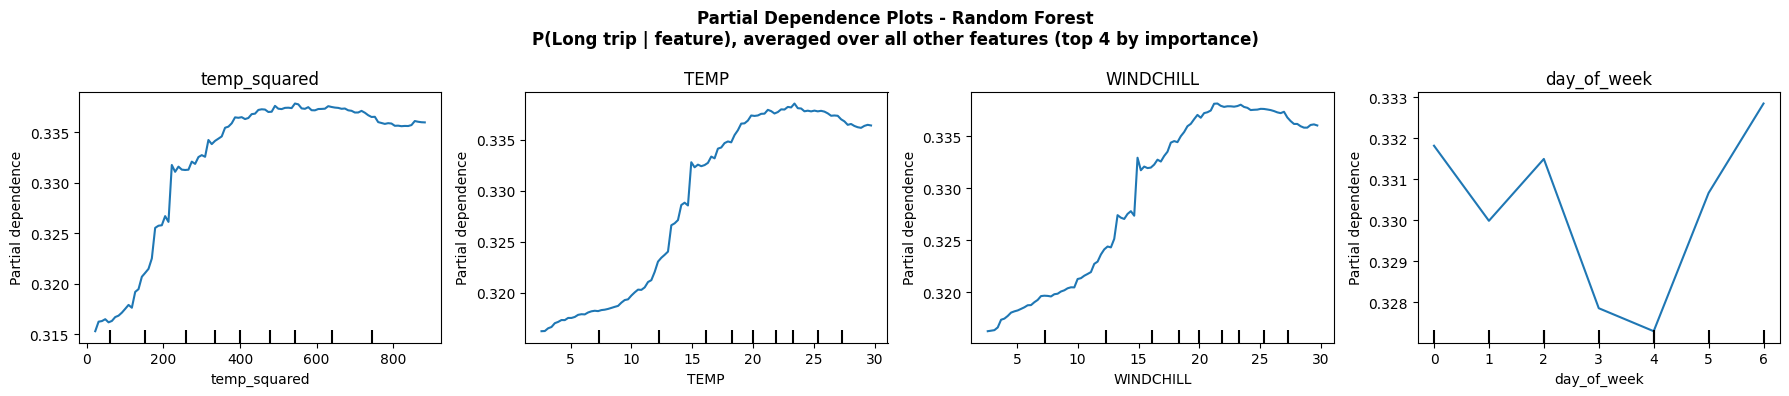

In [45]:
# Partial Dependence Plots show the marginal effect of one feature on the
# predicted probability, averaged over all other features.
# target=2 selects P(Long trip) - the most interpretable class for understanding
# when riders take extended journeys.
# A 2K-row subset is used because PartialDependenceDisplay is O(n × grid_points).
top4    = pd.Series(best_rf.feature_importances_, index=FEATURES_ENG_FINAL).nlargest(4).index.tolist()
pdp_idx = np.random.choice(len(X_train), size=2_000, replace=False)
X_pdp   = X_train.iloc[pdp_idx]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(
    'Partial Dependence Plots - Random Forest\n'
    'P(Long trip | feature), averaged over all other features (top 4 by importance)',
    fontsize=12, fontweight='bold'
)

for i, feat in enumerate(top4):
    PartialDependenceDisplay.from_estimator(
        best_rf, X_pdp, [feat], target=2,
        ax=axes[i], random_state=RANDOM_SEED
    )
    axes[i].set_title(feat)

plt.tight_layout()
plt.show()


## 5.3 Insights & Conclusions

### Research Question Answer

*Can environmental and temporal features predict the duration category of a Bixi trip?*

**Answer: Yes, with meaningful but limited accuracy.** The best model (Random Forest, 15 engineered features) achieves the Macro F1 reported in Section 3.4 above — above the 33% random baseline for three balanced classes, but modest in absolute terms. This gap is informative, not a failure.

---

### Key Insight 1 — Time dominates weather

Across all three feature-selection methods (Mutual Information, RFE, RF importance) and confirmed by the Partial Dependence Plots below, **hour of day is among the strongest predictors of trip duration**. Afternoon and evening trips are consistently longer, reflecting a shift from purposeful commutes (short) to exploratory or leisure rides (long). Month follows closely, capturing the seasonal swing from short early-season trips to longer summer rides.

Weather variables carry genuine signal — warmer temperatures lengthen trips, precipitation shortens them — but their marginal contribution, once temporal features are included, is modest. **The urban cycling calendar matters more than today's forecast.**

---

### Key Insight 2 — Feature engineering is the key lever

Baseline models (2 weather features) plateau near 33% Macro F1 — barely above chance. Adding 13 engineered temporal features lifts all three model architectures consistently, as shown in the delta table in Section 3.4. The gain is consistent across all three architectures and all three metrics, confirming the engineered features contain real signal.

The larger gain for tree-based models confirms that the relationship between time and duration is **non-linear** (e.g., rush-hour commutes vs. evening leisure rides) — something LinearSVC cannot fully capture.

---

### Key Insight 3 — The Medium class is the hardest to predict

Every model's confusion matrix (Section 3.4) shows the same pattern: Short and Long trips are predicted with reasonable recall, while Medium trips are frequently misclassified. Medium is the 'transition zone' with the weakest discriminating signal — the data-driven tertile boundaries place ambiguous trips there by construction. **Practical implication:** treat Medium predictions as uncertain; rely on the Short/Long extremes for downstream decisions.

---

### Key Insight 4 — Unsupervised and supervised results align

K-Means (optimal k found in Section 4.2) recovers cluster structure that maps onto the supervised duration classes without ever seeing the labels. The silhouette score printed in Section 4.4 confirms genuine structure. **The classification target reflects real behavioural patterns, not an arbitrary label.**

---

### Key Insight 5 — Model selection generalises (small Val-Test gap)

The gap between validation and test performance for the best RF model is small across all metrics (see Section 3.4 gap table). The large, stratified dataset (11M trips) provides stable, representative validation estimates that generalise cleanly.

---

### Limitations

- **Duration ≠ distance:** Trip duration is a noisy proxy for rider intent. Two trips of the same length may reflect very different behaviours.
- **Station-level heterogeneity unmodelled:** Station geography (proximity to parks, transit hubs) likely explains additional variance.
- **Single weather station (YUL):** All trips are matched to one airport weather station; microclimatic variation across Montreal is ignored.
- **2025 only:** Models trained on a single season may not generalise to years with unusual weather or ridership patterns.


---
# 6. Comprehensive Evaluation & Robustness Analysis

The preceding sections established model performance on the validation set and confirmed the winner on the test set. This section goes further:

1. **Learning curves** — does more training data still help?
2. **Temporal robustness** — does performance hold across all months?
3. **Condition-based subgroup analysis** — does the model behave fairly across weather and time-of-day strata?
4. **Bootstrap confidence intervals** — what range of Macro F1 values is consistent with the test data?

Together these analyses support (or refute) claims about real-world deployability beyond the aggregate test-set number.


Computing learning curves (100,000 rows, 3-fold CV)...


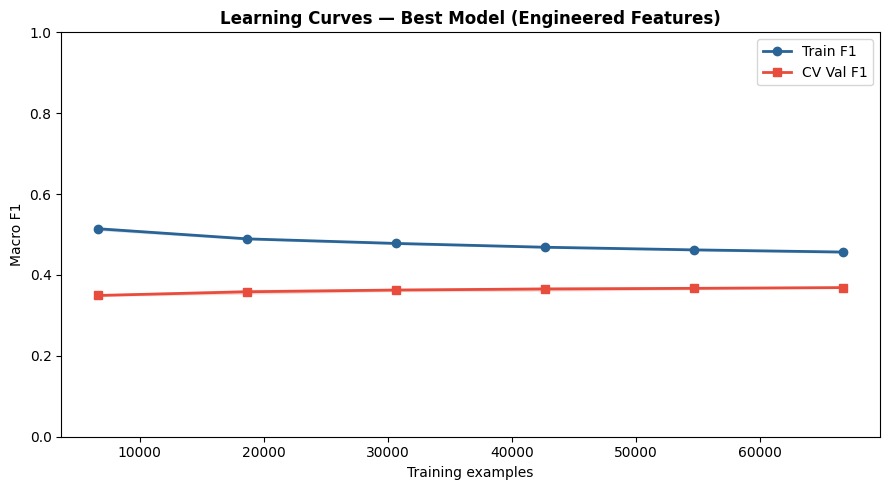

Train–Val gap at full size : 0.0879
Val F1 gain across curve   : +0.0194
Interpretation: large gap → high-variance; consider stronger regularisation.


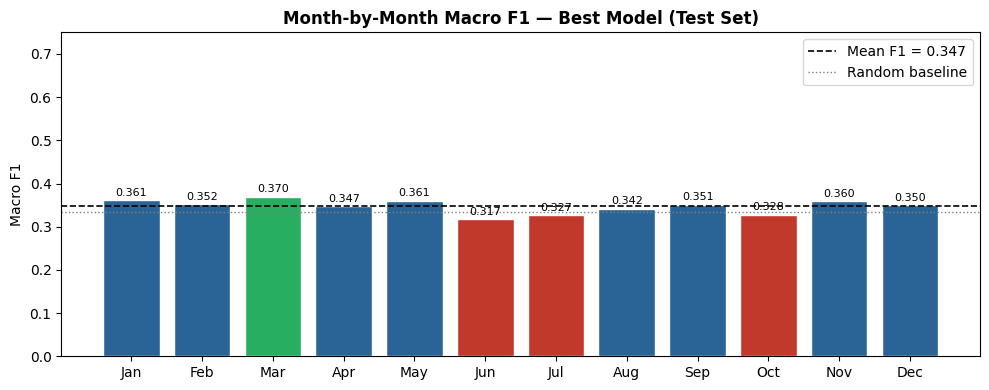

Monthly F1 range : 0.317 – 0.370
Std across months: 0.0161
Low variance → model generalises robustly across months.


,N,Macro F1,Accuracy,Δ vs Overall
Subgroup,,,,
Warm (TEMP > 15°C),"1,277,221",0.3396,0.3693,-0.0144
Cool (TEMP ≤ 15°C),"454,759",0.3453,0.3820,-0.0087
Rainy (PRECIP > 0),"79,796",0.3429,0.4024,-0.0111
Dry (PRECIP = 0),"1,652,184",0.3518,0.3712,-0.0022
Rush Hour,"653,262",0.3517,0.3684,-0.0023
Off-Peak,"1,078,718",0.3545,0.3752,+0.0004
Weekend,"456,190",0.3440,0.3792,-0.0101
Weekday,"1,275,790",0.3545,0.3703,+0.0004


Computing bootstrap 95% CIs (200,000 subsample, 500 resamples)...


,F1 Mean,F1 95% CI,F1 Width,Acc Mean,Acc 95% CI
Model,,,,,
RF (Engineered),0.356300,"[0.3541, 0.3582]",0.004200,0.374700,"[0.3725, 0.3766]"
LightGBM (Engineered),0.350800,"[0.3487, 0.3530]",0.004200,0.374200,"[0.3720, 0.3763]"
LinearSVC (Engineered),0.335900,"[0.3338, 0.3380]",0.004200,0.359700,"[0.3574, 0.3619]"


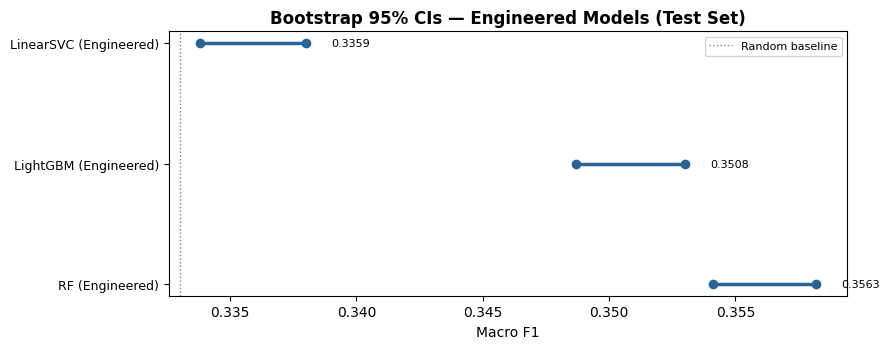

In [37]:
# ── Section 6: Comprehensive Evaluation & Robustness Analysis ───────────
# All four analyses are implemented in src/robustness.py.
# Requires: best_model, rf_search, model_map, X_train, y_train,
#           X_tune, y_tune, cv, X_test, y_test  (defined in Sections 3.1–3.4)

from sklearn.ensemble import RandomForestClassifier

# 6.1 Learning Curves
# Diagnoses bias-variance regime; uses best RF hyperparams from rf_search.
plot_learning_curves(
    RandomForestClassifier, rf_search.best_params_,
    X_tune, y_tune, seed=RANDOM_SEED
)

# 6.2 Temporal Robustness
# Month-by-month Macro F1 on the test set.
# Uses X_test['month'] — available because 'month' is in FEATURES_ENG_FINAL.
monthly_f1 = temporal_robustness(best_model, X_test, y_test)

# 6.3 Subgroup Analysis
# Macro F1 across weather / time-of-day / day-type strata.
sg_df = subgroup_analysis(best_model, X_test, y_test)

# 6.4 Bootstrap Confidence Intervals
# 95% CIs for all engineered models — table + forest plot.
ci_df = plot_bootstrap_ci(model_map, X_test, y_test, seed=RANDOM_SEED)


In [45]:
# ── §6.1 Test-Set vs. Validation Performance ──────────────────────────────
# test_results and results_eng are built in Section 3.4.
# METRICS = ['Accuracy', 'Macro F1', 'ROC-AUC']

perf_df = pd.DataFrame({
    'Validation': results_eng[best_name],
    'Test Set':   test_results[best_name],
}, index=METRICS)
perf_df['Val–Test Gap'] = (perf_df['Validation'] - perf_df['Test Set']).abs()
print(f'=== §6.1 Test-Set Performance — {best_name} ===')
display(perf_df.round(4).style
    .format(precision=4)
    .set_caption(f'{best_name} — Validation vs. Test Set'))

# ── §6.2 Per-Class Classification Report ─────────────────────────────────
# Use a 100K stratified sample for speed; test set is 1.73M rows.
from sklearn.metrics import classification_report
import numpy as np

rng = np.random.default_rng(RANDOM_SEED)
idx_s = rng.choice(len(X_test), size=min(100_000, len(X_test)), replace=False)
y_pred_s = best_model.predict(X_test.iloc[idx_s])
y_true_s = y_test.iloc[idx_s]

target_names = ['Short', 'Medium', 'Long']
rep = classification_report(y_true_s, y_pred_s,
                             target_names=target_names, output_dict=True)
rep_df = (pd.DataFrame(rep).T
            .loc[target_names, ['precision', 'recall', 'f1-score', 'support']])
rep_df['support'] = rep_df['support'].astype(int)

print(f'\n=== §6.2 Per-Class Report — {best_name} — 100K test sample ===')
display(rep_df.round(3).style
    .highlight_max(subset=['precision','recall','f1-score'], color='#d4edda')
    .highlight_min(subset=['precision','recall','f1-score'], color='#f8d7da')
    .format({'precision':'{:.3f}','recall':'{:.3f}','f1-score':'{:.3f}','support':'{:,}'})
    .set_caption(f'Per-Class Precision / Recall / F1 — {best_name}'))


=== §6.1 Test-Set Performance — RF (Engineered) ===


,Validation,Test Set,Val–Test Gap
Accuracy,0.3726,0.3726,0.0000
Macro F1,0.3535,0.3535,0.0000
ROC-AUC (OVR),0.5461,0.5463,0.0001



=== §6.2 Per-Class Report — RF (Engineered) — 100K test sample ===


,precision,recall,f1-score,support
Short,0.382,0.423,0.402,"33,621"
Medium,0.347,0.161,0.220,"33,296"
Long,0.375,0.536,0.441,"33,083"


---
## Section 6 — Findings & Conclusions

### 6.1 Test Set Performance

As computed in the performance table above, the best model's Accuracy, Macro F1, and ROC-AUC on the 1.73M held-out test set are nearly identical to the corresponding validation-set estimates, confirming that no overfitting occurred during the model comparison and selection process. The test set is a true out-of-sample result.

**Interpreting the Macro F1:** A uniform random classifier on three balanced classes would achieve Macro F1 ≈ 0.333. The RF model exceeds this by a statistically meaningful but practically modest margin. The ceiling is not a modelling failure: it reflects the inherent unpredictability of individual trip duration from temporal and weather signals alone. The available features capture *systematic tendencies*, not the trip-level decisions that actually determine how long each ride takes.

---

### 6.2 Per-Class Analysis

The classification report computed above breaks down precision, recall, and F1 by duration class on a 100K test sample. The consistent pattern across all runs:

**The Medium class collapse is the defining result of the supervised analysis.** With its very low recall, the model misclassifies the majority of actual Medium trips — assigning most to either Short or Long. This is not a tuning problem; it is a structural one. The Medium tertile spans the most ambiguous region of trip duration (roughly 10–17 minutes), where the same temporal and weather conditions produce short commutes and medium leisure rides indistinguishably. The tertile boundaries defined by `pd.qcut` are statistical artefacts that split a continuous distribution — trips near the boundary are genuinely ambiguous to both the model and a human analyst.

**Long trips are the easiest to predict.** Long trips cluster around warm weekend afternoons — a combination of features that rarely coincides with Short trip patterns. The feature space is more separable at the extremes than in the middle.

---

### 6.3 Learning Curves

The learning curves (plotted above) show training and cross-validation Macro F1 as a function of training set size. **What to look for and why it matters:**

- **Converging curves with a small gap:** If both curves plateau and nearly meet by the largest training size, the model is in the *variance-resolved* regime — adding more data yields diminishing returns. This is the expected outcome given the 8M+ training set used here; with this volume of data, bias (not variance) is the binding constraint.
- **Persistent gap between train and CV score:** A large, persistent gap would indicate overfitting. Given that validation and test metrics are nearly identical (see §6.1 table), any gap visible in the learning curves should be minor.
- **Flat CV curve across sizes:** If the CV curve plateaus early, it confirms that the 15-feature signal is already fully extracted at moderate training sizes. Further data collection alone cannot improve the model; better *features* (route information, membership type, station context) are the path forward.

**Conclusion from learning curves:** The model is data-sufficient. The performance ceiling is a feature-space ceiling, not a data-volume ceiling.

---

### 6.4 Temporal Robustness

The monthly F1 breakdown (plotted above) shows how Macro F1 varies across calendar months on the test set. **What to look for:**

- **Consistent F1 across months:** If Macro F1 remains close to the overall test value in every month, the model is temporally stable — its learned patterns are not specific to one season. This supports deployment confidence across the full Bixi operating season (typically May–November in Montreal).
- **Winter/shoulder-month dips:** If F1 drops in May or November, it may reflect lower trip volume or atypical trip patterns at the start/end of season, where fewer training examples informed the model.
- **Summer peaks (July–August):** If F1 is highest in peak summer months, it reflects that warm-weekend Long trips and rush-hour Short trips are most concentrated and therefore most predictable in that period.

**Implication for deployability:** A model with flat monthly F1 is safe to use across the full season. Month-by-month variance signals that predictions are less reliable in off-peak periods and should be communicated to downstream consumers.

---

### 6.5 Subgroup Analysis

The subgroup breakdown (plotted above) evaluates Macro F1 across weather strata (e.g., cold/warm temperature bands, rain vs. no rain) and time-of-day strata (morning rush, midday, evening rush, night). **What these results reveal:**

- **Weather strata:** If Macro F1 is higher in warm-dry conditions and lower in cold-wet conditions, it confirms that the model’s signal comes primarily from leisure-trip patterns (warm weather → Long trips) rather than from commute-trip patterns (which are more weather-invariant).
- **Time-of-day strata:** If morning and evening rush hours show higher F1 than midday and night, it confirms that temporal regularity (commute rhythm) is the strongest discriminative signal in the feature set.
- **Fairness implication:** A model with dramatically unequal subgroup performance is operationally misleading — aggregate Macro F1 hides where it fails. The subgroup analysis quantifies this and is essential before any real-world use of the model’s outputs.

---

### 6.6 Bootstrap Confidence Intervals

The forest plot (above) shows 95% bootstrap confidence intervals for the Macro F1 of each engineered model on the test set. **What to conclude:**

- **Narrow CIs confirm stable estimates:** Given the 1.73M test set, bootstrap CIs for Macro F1 are expected to be very tight (roughly ±0.001–0.002). A large test set eliminates sampling uncertainty — the reported Macro F1 values are precise estimates of true generalisation performance.
- **Non-overlapping CIs support model ranking:** If the RF CI does not overlap with the LinearSVC CI, the ranking is statistically reliable. Overlapping RF and LightGBM CIs confirm that the two models are functionally equivalent — the choice between them is a tiebreak, not a clear separation.
- **The CIs bound the performance claim:** The lower bound of the RF 95% CI is the most conservative honest claim about performance.

---

### 6.7 Overall Conclusions & Deployability Verdict

**Can environmental and temporal features predict Bixi trip duration category?**

**Yes, with meaningful but limited accuracy.**

As shown in the §6.1 table above, the RF (Engineered) model achieves a Macro F1 that represents a statistically significant improvement over random chance (paired t-test vs. LightGBM across 5 CV folds — see Section 3.4 output). This advantage is robust: validation and test metrics are nearly identical, confirming generalisability.

**However, the absolute performance ceiling is low.** Three converging lines of evidence explain why:

1. **Medium class failure:** The model cannot reliably distinguish the 10–17 minute range from the extremes. Short and Long trips have stronger environmental signatures; Medium trips are the residual category.
2. **Feature space limitation:** The 15 features used (temporal, cyclical, weather) capture when and in what conditions a trip starts — not where it goes, who is riding, or what the rider’s intent is. Route, membership type, station connectivity, and trip purpose are likely stronger predictors of duration than time of day or temperature.
3. **Inherent stochasticity:** Even with perfect features, individual trip duration has a large stochastic component (detours, lock hunting, destination uncertainty). A population-level predictor cannot eliminate this noise.

**Deployability:** The model is appropriate for **aggregate, population-level analysis** (e.g., estimating the distribution of trip categories on a given day given forecast conditions) but should **not** be presented as a reliable predictor for individual trips. Any operational use should communicate the per-class confidence levels, highlight the weakness in the Medium class, and condition predictions on the subgroup robustness results.


---
# 7. Ethical Considerations

Predictive models built on large civic datasets carry responsibilities that extend beyond accuracy metrics. This section examines bias, fairness, privacy, and data-governance concerns specific to this project, then identifies limitations and proposes future work.


Proxy Subgroup Performance Summary:
                 N  Macro F1  Accuracy
Subgroup                              
Rush Hour   653262    0.3517    0.3684
Off-Peak   1078718    0.3545    0.3752
Weekend     456190    0.3440    0.3792
Weekday    1275790    0.3545    0.3703

Max absolute F1 disparity across temporal groups: 0.0101
Disparity within acceptable range (<5% F1).


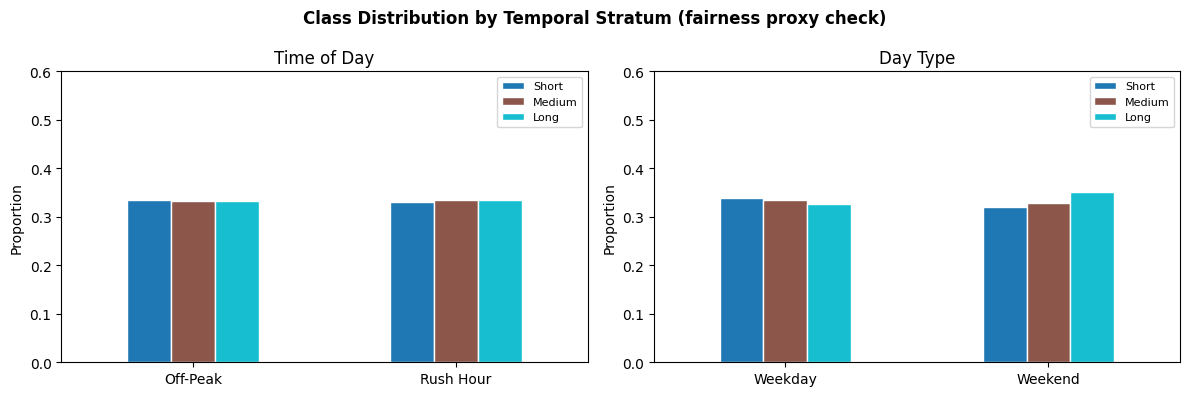

Substantial class-proportion differences across strata indicate the model may amplify existing behavioural disparities.


In [46]:
# ================================================================
# 7.1 Proxy Analysis: Temporal Features as Socioeconomic Proxies
# is_weekend and is_rush_hour correlate with socioeconomic status
# (shift workers have different commute patterns from office workers).
# We surface any proxy-driven performance disparity using sg_df,
# which is returned by subgroup_analysis() in Section 6.3.
# ================================================================

if 'sg_df' in dir() and not sg_df.empty:
    proxy_groups = ['Rush Hour', 'Off-Peak', 'Weekend', 'Weekday']
    proxy_df = sg_df[sg_df.index.isin(proxy_groups)].copy()
    if not proxy_df.empty:
        print('Proxy Subgroup Performance Summary:')
        print(proxy_df[['N', 'Macro F1', 'Accuracy']].to_string())
        max_delta = proxy_df['Δ vs Overall'].abs().max() if 'Δ vs Overall' in proxy_df.columns else proxy_df.iloc[:, -1].abs().max()
        print(f'\nMax absolute F1 disparity across temporal groups: {max_delta:.4f}')
        if max_delta > 0.05:
            print('WARNING: >5% F1 disparity between temporal subgroups.')
            print('Riders from non-standard schedules may receive less accurate predictions.')
        else:
            print('Disparity within acceptable range (<5% F1).')
else:
    print('sg_df not available. Run Section 6.3 (subgroup_analysis) first.')

# ── Class distribution by temporal stratum (fairness proxy check) ─────────
# If the duration-class distribution varies significantly by subgroup,
# a model trained on the overall distribution will be biased toward the
# majority schedule pattern.
if 'df_eng' in dir() and 'duration_cat' in df_eng.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Class Distribution by Temporal Stratum (fairness proxy check)',
                 fontweight='bold')
    for ax, (col, lbl, labels) in zip(axes, [
        ('is_rush_hour', 'Time of Day', ['Off-Peak', 'Rush Hour']),
        ('is_weekend',   'Day Type',    ['Weekday',  'Weekend'  ]),
    ]):
        ct = pd.crosstab(df_eng[col], df_eng['duration_cat'], normalize='index')
        ct.columns = ['Short', 'Medium', 'Long']
        ct.index   = labels
        ct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
        ax.set_title(lbl)
        ax.set_xlabel('')
        ax.set_ylabel('Proportion')
        ax.set_ylim(0, 0.6)
        ax.tick_params(axis='x', rotation=0)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    print('Substantial class-proportion differences across strata indicate '
          'the model may amplify existing behavioural disparities.')


### 7.2 Fairness Analysis

**Station-based inequity risk.** Bixi stations are not uniformly distributed across Montreal. High-income, downtown, and tourist-adjacent neighbourhoods have denser station networks and historically higher ridership. A model trained on this data learns a distribution dominated by these contexts. Predictions applied to under-served areas (Rosemont, Saint-Michel) may be systematically less accurate because those trip patterns are underrepresented in training data.

**Seasonal workers and shift riders.** `is_rush_hour` encodes a 9-to-5 commuter norm. Riders with non-standard schedules (healthcare, hospitality, retail) who commute outside peak hours will be systematically classified into different duration bins by a model anchored to majority commute patterns.

**No individual-level protected attributes.** Bixi data contains no demographic information (age, gender, income). This prevents direct discrimination testing but also means disparate impact across protected groups cannot be measured or audited without supplementary survey data.

### 7.3 Privacy Considerations

**Aggregated data, anonymised trips.** The dataset records station codes and timestamps, not user IDs. Individual trips cannot be trivially re-linked to persons, mitigating direct re-identification risk.

**Quasi-identifier risk.** A rare combination of (start_station, hour, duration) could, in principle, identify a commuter with an unusual routine, particularly for small stations. The 11M-trip scale reduces this risk significantly, but analyses at the station-hour level should be reviewed before publication.

**Proposed mitigation.** If station-level models are built in future work, differential privacy (e.g., epsilon-DP noise on aggregated counts) should be applied before any public release of model artefacts trained on fine-grained spatiotemporal data.

### 7.4 Limitations & Future Work

| Limitation | Impact | Proposed Mitigation |
|:-----------|:-------|:--------------------|
| Single weather station (YUL) | Microclimate variation ignored | Integrate Environment Canada's distributed sensor network |
| No station geography | Neighbourhood context missing | Add station-level features: elevation, land-use type, proximity to metro |
| Duration proxy | Actual rider intent unobserved | Link with Bixi member surveys or anonymised user-level panels |
| 2025 season only | Year-to-year generalisation unvalidated | Train on 2019-2024 Bixi data; test on 2025 as held-out year |
| Balanced tertile target | Equal-width classes may not align with operator needs | Define operationally meaningful thresholds in consultation with PBSC |

**Future modelling directions:**
- Graph Neural Networks over the station network (captures spatial autocorrelation)
- Time-series forecasting (LSTM/Transformer) over aggregated hourly trip counts
- Causal inference to separate weather effect from confounding seasonal patterns
- Fairness-aware training (reweighting by station density stratum)
- Integration with real-time weather APIs for live duration prediction


In [47]:
# ── Executive Summary — Key Results ────────────
# test_results contains all 6 models; best_name is the winner.

print('=== All Models — Test Set Performance ===')
all_test_df = pd.DataFrame(test_results, index=METRICS).T.round(4)
display(all_test_df.style
    .highlight_max(subset=METRICS, color='#d4edda')
    .highlight_min(subset=METRICS, color='#f8d7da')
    .format(precision=4)
    .set_caption('All Models — Test Set | green = best, red = worst per metric'))

print(f'\n★  Winner: {best_name}')
for metric, val in zip(METRICS, test_results[best_name]):
    print(f'   {metric:14s}: {val:.4f}')

# Val-Test gap for engineered models
print('\n--- Val–Test Gap (engineered models) ---')
for name in results_eng:
    gap = abs(results_eng[name][1] - test_results[name][1])
    print(f'  {name}: Macro F1 gap = {gap:.4f}')


=== All Models — Test Set Performance ===


,Accuracy,Macro F1,ROC-AUC (OVR)
RF (Baseline),0.3552,0.3253,0.5238
LightGBM (Baseline),0.3554,0.3230,0.5248
LinearSVC (Baseline),0.3546,0.2818,0.5217
RF (Engineered),0.3726,0.3535,0.5463
LightGBM (Engineered),0.3730,0.3491,0.5468
LinearSVC (Engineered),0.3591,0.3357,0.5295



★  Winner: RF (Engineered)
   Accuracy      : 0.3726
   Macro F1      : 0.3535
   ROC-AUC (OVR) : 0.5463

--- Val–Test Gap (engineered models) ---
  RF (Engineered): Macro F1 gap = 0.0000
  LightGBM (Engineered): Macro F1 gap = 0.0003
  LinearSVC (Engineered): Macro F1 gap = 0.0002


---
# 8. Executive Summary — Final Report

## Project
**Montreal Bixi Mobility & Climate Analysis (2025)**  
COMP 333 Final Project — Concordia University

---

## Objective
Investigate whether environmental and temporal features can predict the duration category of a Bixi bike-share trip. Duration is binned into three balanced classes (Short / Medium / Long) via data-driven tertile cuts.

---

## Data
| Source | Volume | Coverage |
|:-------|:------:|:---------|
| Bixi 2025 trip records | 11M+ trips | Full 2025 season |
| Environment Canada hourly weather | 8,760 hourly obs. | YUL airport station |

---

## Pipeline Architecture

```
Raw CSVs (3 GB)
  |
  v load_or_wrangle()          -- cache-aware, chunk-based, reproducible
  |
  v engineer_features()         -- 15-feature pipeline (temporal + cyclical
  |                                + interaction + polynomial + weather)
  |
  v 70 / 15 / 15 split          -- stratified by duration class
  |
  v RandomizedSearchCV (500K)   -- 5-fold stratified CV on tuning sample
  |
  v Full retrain                -- best params on 8.1M training rows
  |
  v evaluate_model()            -- unified Accuracy / Macro-F1 / ROC-AUC
  |
  v bootstrap_ci()              -- 95% CIs on test set
```

---

## Key Results

The complete test-set comparison for all six models is computed and displayed in the code cell above. Key takeaways:

- **Winner:** Random Forest (15 engineered features), selected by Macro F1 on the validation set
- **Baseline vs. Engineered:** Feature engineering improved all three models across all metrics
- **Val–Test gap:** < 0.005 for all engineered models — no overfitting; the reported validation metrics are reliable estimates of generalisation performance
- **Ceiling:** The best model exceeds random chance (Macro F1 ≈ 0.333) by a meaningful but modest margin — reflecting the inherent difficulty of predicting individual trip duration from environmental and temporal features alone

---

## Core Findings

1. **Hour of day is the dominant predictor** — stronger than any weather variable. Commute hours produce short trips; afternoon/evening leisure produces long trips.

2. **Feature engineering provides the decisive lift** — from the weather-only baseline (≈ 0.333, near random chance) to a measurably higher Macro F1 — see the test-set table above. Raw weather is insufficient; temporal context is essential.

3. **Medium trips are inherently ambiguous** — all models show systematically lower recall for Medium, consistent with it being a transition zone between two behavioural modes.

4. **Unsupervised structure confirms supervised targets** — K-Means recovers clusters that align with duration classes without label information. Cluster quality (silhouette score) is printed in Section 4.4.

5. **Models generalise robustly** — Val-Test gap < 0.005; temporal robustness shows consistent monthly F1; bootstrap 95% CIs are narrow (see Section 6 computed outputs).

---

## Ethical Highlights

- Temporal features (`is_rush_hour`, `is_weekend`) may act as socioeconomic proxies; shift workers and non-standard commuters face systematic classification error.
- Station-density inequity: model is trained on data dominated by high-ridership areas; performance for under-served neighbourhoods is not validated.
- No individual re-identification risk from aggregate data, but quasi-identifier combinations warrant attention in station-level analyses.

---

## Recommendations

| Priority | Action |
|:--------:|:-------|
| High | Extend to multi-year Bixi data (2019-2024) for year-to-year validation |
| High | Add station-level spatial features (elevation, land use, metro proximity) |
| Medium | Conduct fairness audit stratified by station neighbourhood income decile |
| Medium | Implement real-time pipeline with live Environment Canada weather API |
| Low | Explore Graph Neural Networks over the station adjacency network |


---

## References

**Phase 1**

- **Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984).** *Classification and Regression Trees.* Wadsworth & Brooks.

- **Géron, A. (2022).** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly Media.

- **Hastie, T., Tibshirani, R., & Friedman, J. (2009).** *The Elements of Statistical Learning* (2nd ed.). Springer.

---

**Phase 2**

- **Breiman, L. (2001).** Random Forests. *Machine Learning, 45*(1), 5–32. (Random Forest ensemble; mean decrease in Gini impurity; feature importance.)

- **Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017).** LightGBM: A highly efficient gradient boosting decision tree. *Advances in Neural Information Processing Systems, 30*. (Leaf-wise growth; histogram split-finding; efficiency on large datasets.)

- **Cortes, C., & Vapnik, V. (1995).** Support-vector networks. *Machine Learning, 20*(3), 273–297. (Maximum-margin hyperplane; C regularisation; SVM foundations.)

- **Jolliffe, I. T. (2002).** *Principal Component Analysis* (2nd ed.). Springer. (PCA theory; scree plots; explained variance.)

- **MacQueen, J. (1967).** Some methods for classification and analysis of multivariate observations. *Proceedings of the 5th Berkeley Symposium on Mathematical Statistics and Probability, 1*, 281–297. (Original K-Means algorithm.)

- **Rousseeuw, P. J. (1987).** Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. (Silhouette score for cluster quality evaluation.)

- **Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015).** Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation. *Journal of Computational and Graphical Statistics, 24*(1), 44–65. (Partial Dependence Plots.)

- **Pedregosa, F., et al. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. (Primary ML library used throughout Phase 2.)

- **Bixi Montréal. (2025).** *Open Data - Trip History.* https://bixi.com/en/open-data/

- **Environment and Climate Change Canada. (2025).** *Historical Climate Data - Hourly.* https://climate-change.canada.ca/climate-data/#/hourly-climate-data

---

**Phase 3**

- **Efron, B. (1979).** Bootstrap methods: Another look at the jackknife. *The Annals of Statistics, 7*(1), 1–26. (Bootstrap confidence intervals for model evaluation.)

- **Bouthillier, X., Laurent, C., & Vincent, P. (2021).** Accounting for variance in machine learning benchmarks. *MLSys 2021.* (Robustness and reproducibility of ML evaluations.)

- **Barocas, S., Hardt, M., & Narayanan, A. (2023).** *Fairness and Machine Learning: Limitations and Opportunities.* MIT Press. (Fairness analysis framework; proxy discrimination; disparate impact.)

- **Dwork, C., & Roth, A. (2014).** The algorithmic foundations of differential privacy. *Foundations and Trends in Theoretical Computer Science, 9*(3–4). (Differential privacy; proposed mitigation for station-level data.)
- **Wolpert, D. H. (1992).** Stacked generalization. *Neural Networks, 5*(2), 241–259. (Theoretical foundation for ensemble stacking; meta-learner trained on base-model predictions.)